In [1]:
import os

if os.getcwd().split("/")[-1] != "neurolib":
    os.chdir('..')

os.chdir('..')
datadir = os.path.join(os.getcwd(), "neurolib", "whole-brain")
print(datadir)

/home/lena/Promotion/neurolib/neurolib/whole-brain


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
import pickle

from neurolib.models.wc import WCModel
from neurolib.control.optimal_control import oc_wc, cost_functions

import nctpy.utils
import nctpy.metrics
import pandas as pd
import seaborn as sns

# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

import matplotlib as mpl
label_size= 20
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
mpl.rcParams['font.size'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['figure.titlesize'] = label_size
mpl.rcParams['lines.linewidth'] = 1


def ploterrorrange(a, x_axis, linfit, linfitstd):
    xpos = np.linspace(0., x_axis[-1], 100)
    a.fill_between(xpos, linfit[1]-linfitstd[1] + xpos*(linfit[0]-linfitstd[0]), linfit[1] + xpos*linfit[0], color="red", alpha=0.3 )
    a.fill_between(xpos, linfit[1] + xpos*linfit[0], linfit[1]+linfitstd[1] + xpos*(linfit[0]+linfitstd[0]), color="red", alpha=0.3 )
    xneg = np.linspace(x_axis[0], -1e-3, 100, )
    a.fill_between(xneg, linfit[1]-linfitstd[1] + xneg*(linfit[0]+linfitstd[0]), linfit[1] + xneg*linfit[0], color="red", alpha=0.3 )
    a.fill_between(xneg, linfit[1] + xneg*linfit[0], linfit[1]+linfitstd[1] + xneg*(linfit[0]-linfitstd[0]), color="red", alpha=0.3 )

def get_sphere_coords(x,y,z):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(z/r)
    phi = np.sign(y)*np.arccos(x/np.sqrt(x**2 + y**2))
    return r, theta, phi

In [3]:
N = 100

folders = ["NAP_002", "NAP_003", "NAP_005", "NAP_007", "NAP_009", "NAP_010", "NAP_011", "NAP_012", "NAP_013", "NAP_014", "NAP_015", "NAP_016", "NAP_018", "NAP_020", "NAP_022", "NAP_024", "NAP_025", "NAP_026", "NAP_027", "NAP_028", "NAP_029", "NAP_031", "NAP_032", "NAP_033", "NAP_035", "NAP_036"]
cmat_sum = np.zeros((N,N))
dmat_sum = np.zeros((N,N))

for f in folders:
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_CM.mat")
    cmat_sum += scipy.io.loadmat(path)["SC"]
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_LEN.mat")
    dmat_sum += scipy.io.loadmat(path)["LEN"]

cmat_av = cmat_sum/len(folders)
dmat_av = dmat_sum/len(folders)

coord_data = pd.read_csv(os.path.join(os.getcwd(), "data", "structural_data", "Sch100_coords.txt"), sep=None, header=None).to_numpy()

/tmp/ipykernel_2759375/854259224.py:16: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support sep=None with delim_whitespace=False; you can avoid this warning by specifying engine='python'.
  coord_data = pd.read_csv(os.path.join(os.getcwd(), "data", "structural_data", "Sch100_coords.txt"), sep=None, header=None).to_numpy()


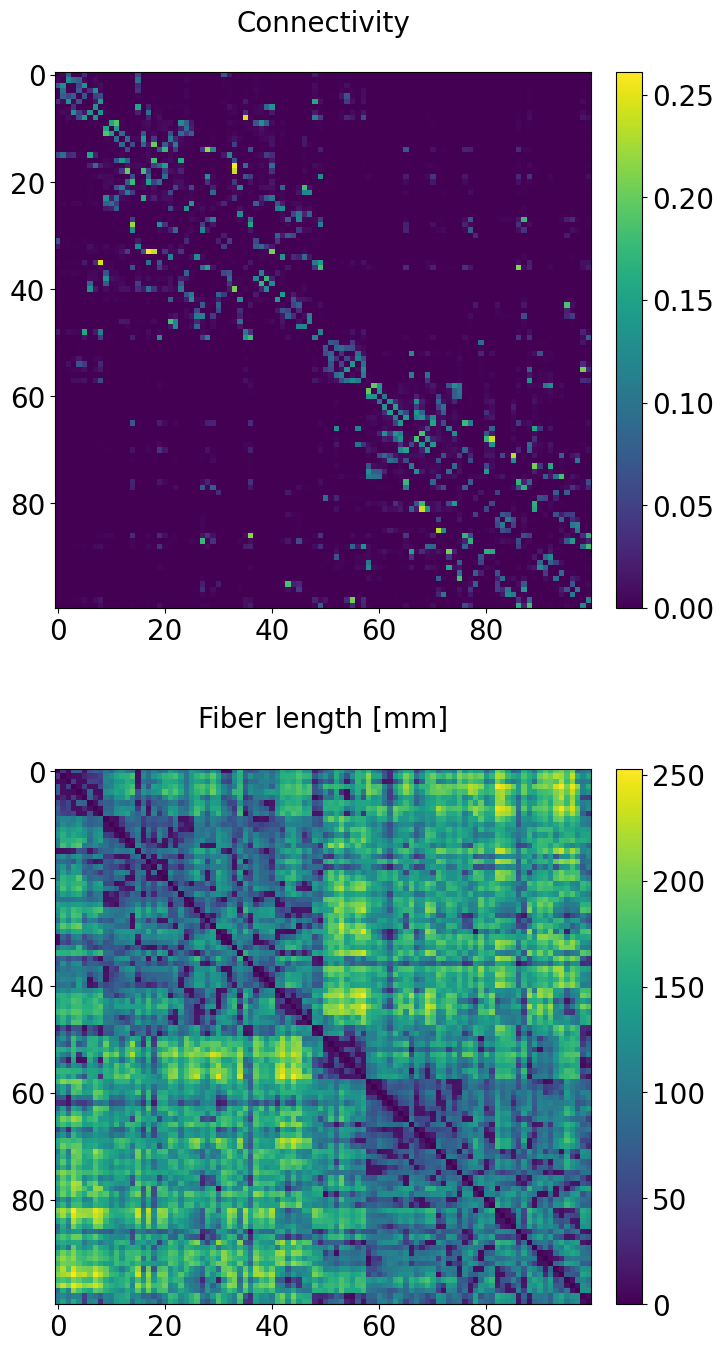

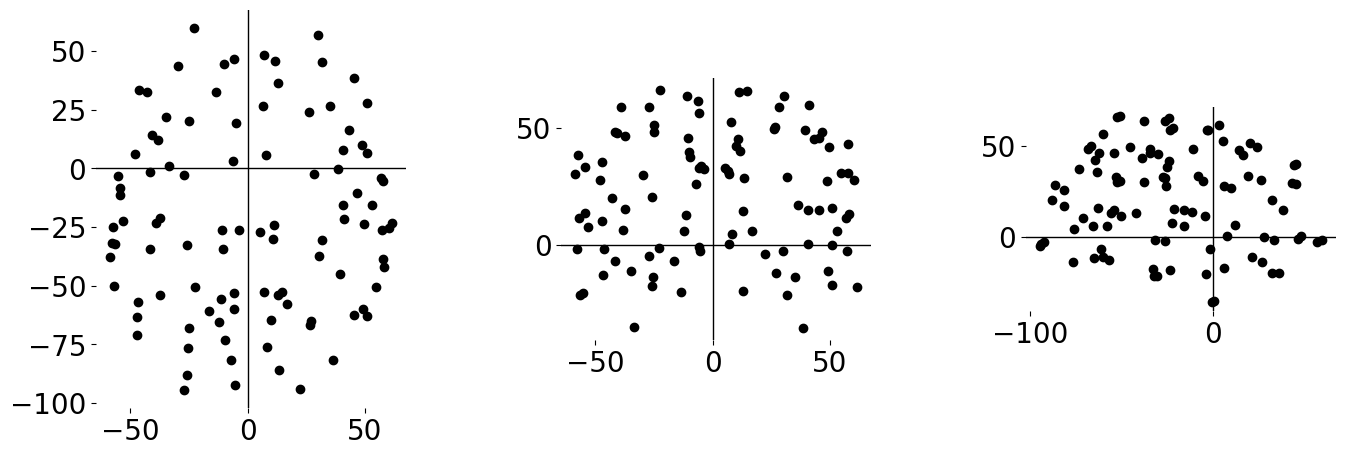

In [4]:
fig, ax = plt.subplots(2,1, figsize=(8,16))

ax[0].set_aspect('equal', adjustable='box')
ax[1].set_aspect('equal', adjustable='box')

heatmap = ax[0].imshow(cmat_av)
ax[0].set_title("Connectivity\n")
bar = plt.colorbar(heatmap, fraction=0.046, pad=0.04)

heatmap = ax[1].imshow(dmat_av)
ax[1].set_title("Fiber length [mm]\n")
bar = plt.colorbar(heatmap, fraction=0.046, pad=0.04)

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.0, hspace=0.3)

plt.savefig(os.path.join(datadir, "cd_mat.jpg"), bbox_inches='tight', dpi=300)
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(16,6))

for n in range(N):
    ax[0].plot(coord_data[n,0], coord_data[n,1], marker="o", color="k")
    ax[1].plot(coord_data[n,0], coord_data[n,2], marker="o", color="k")
    ax[2].plot(coord_data[n,1], coord_data[n,2], marker="o", color="k")


for k in range(3):
    ax[k].set_aspect('equal', adjustable='box')
    ax[k].axhline(y=0, color='k')
    ax[k].axvline(x=0, color='k')

    #ax[k].get_xaxis().set_visible(False)

    ax[k].spines['right'].set_visible(False)
    ax[k].spines['left'].set_visible(False)
    ax[k].spines['top'].set_visible(False)
    ax[k].spines['bottom'].set_visible(False)

plt.subplots_adjust(left=None, bottom=0.1, right=None, top=None, wspace=0.5, hspace=0.1)
plt.box(False)
plt.show()

In [5]:
sys = "discrete"

c_norm = nctpy.utils.matrix_normalization((cmat_av), system=sys)
av_c = nctpy.metrics.ave_control(c_norm, sys)
mod_c = nctpy.metrics.modal_control(c_norm)
wnd = np.sum(cmat_av, axis=0)
nfl = np.sum(dmat_av, axis=0)

nfl -= np.amin(nfl)
nfl /= 1e3

wnfl = np.zeros((N))
for n in range(N):
    wnfl[n] = sum(cmat_av[n,:]*dmat_av[n,:])

r, theta, phi = get_sphere_coords(coord_data[:,0], coord_data[:,1], coord_data[:,2])

rng = np.random.default_rng()
method = scipy.stats.PermutationMethod(n_resamples=2. * 1e3, random_state=rng)
cmap = "cividis"

In [6]:
x_array = [av_c, mod_c, wnd, nfl, coord_data[:,0], coord_data[:,1], coord_data[:,2], r]
xlabel = ["Average controllability", "Modal controllability", "Weighted node degree", "Relative fiber length", "x coordinate", "y coordinate", "z coordinate", "r coordinate"]

r_mat_cd_cd = np.zeros((len(x_array), len(x_array)))
p_mat_cd_cd = np.zeros((len(x_array), len(x_array)))

for ix, x in enumerate(x_array):
    for iy, y in enumerate(x_array):

        if iy == ix: 
            r_mat_cd_cd[ix, iy] = 1.
            p_mat_cd_cd[ix, iy] = 0.

        if iy >= ix: continue

        result = scipy.stats.pearsonr(x, y, method=method)
        r_val = result.statistic
        p_val = result.pvalue
        r_mat_cd_cd[ix, iy] = r_val
        r_mat_cd_cd[iy, ix] = r_val
        p_mat_cd_cd[ix, iy] = p_val
        p_mat_cd_cd[iy, ix] = p_val

In [ ]:
xlabel = ["Average controllability", "Modal controllability", "Weighted node degree", "Relative fiber length", "x coordinate", "y coordinate", "z coordinate", "r coordinate"]

annotations = r_mat_cd_cd.copy()

for ix in range(len(xlabel)):
    annotations[ix, ix] = None

plt.figure(figsize=(16,16))
ax = sns.heatmap(annotations, annot=True, fmt='.3f', cmap=cmap, yticklabels=xlabel, xticklabels=xlabel, vmin=-1, vmax=1)
ax.set_aspect('equal', adjustable='box')
plt.savefig(os.path.join(datadir, "cd_cd_0.jpg"), bbox_inches='tight', dpi=300)
plt.show()

for ix in range(len(xlabel)):
    for iy in range(len(xlabel)):
        if p_mat_cd_cd[ix, iy] >= 0.05:
            annotations[ix, iy] = None

plt.figure(figsize=(16,16))
ax = sns.heatmap(annotations, annot=True, fmt='.3f', cmap=cmap, yticklabels=xlabel, xticklabels=xlabel, vmin=-1, vmax=1)
ax.set_aspect('equal', adjustable='box')
plt.savefig(os.path.join(datadir, "cd_cd_1.jpg"), bbox_inches='tight', dpi=300)
plt.show()

for ix in range(len(xlabel)):
    for iy in range(len(xlabel)):
        if np.abs(r_mat_cd_cd[ix, iy]) < 0.0:
            annotations[ix, iy] = None

plt.figure(figsize=(16,16))
ax = sns.heatmap(annotations, annot=True, fmt='.3f', cmap=cmap, yticklabels=xlabel, xticklabels=xlabel, vmin=-1, vmax=1)
ax.set_aspect('equal', adjustable='box')
plt.savefig(os.path.join(datadir, "corr_mat_cd.jpg"), bbox_inches='tight', dpi=300)
plt.show()

annotations = np.delete(annotations, 1, 0)
annotations =  np.delete(annotations, 1, 1)

plt.figure(figsize=(16,16))
ax = sns.heatmap(annotations, annot=True, fmt='.3f', cmap=cmap, yticklabels=np.delete(xlabel, 1, 0), xticklabels=np.delete(xlabel, 1, 0), vmin=-1, vmax=1)
ax.set_aspect('equal', adjustable='box')
plt.savefig(os.path.join(datadir, "corr_mat_cd_minM.jpg"), bbox_inches='tight', dpi=300)
plt.show()

In [135]:
with open(os.path.join(datadir, 'wb.pickle'), 'rb') as f:
    data_read = pickle.load(f)
[d0_var_L2, d1_var_L2, d2_var_L2] = data_read

with open(os.path.join(datadir, 'wb_L1.pickle'), 'rb') as f:
    data_read = pickle.load(f)
[d0_var_L1, d1_var_L1, d2_var_L1] = data_read

with open(os.path.join(datadir, 'wb_cc.pickle'), 'rb') as f:
    data_read = pickle.load(f)
[d0_cc_L2, d1_cc_L2, d2_cc_L2] = data_read

dt = 0.1

rng = np.random.default_rng()
method = scipy.stats.PermutationMethod(n_resamples=2. * 1e3, random_state=rng)
cmap = "cividis"

In [151]:
i0, i1 = 60, 450
i0a, i1a = 2780, 3280
i0a0, i1a0 = 3200, 3650
wi = 0
lim = 1e-8

## cost combo / point task / weight / n

peak_times = np.zeros((4, 3, 3, N))
energy = np.zeros((4, 3, 3, N))
input = np.zeros((4, 3, 3, N))
control_times = np.zeros((4, 3, 3, N))

wi_ = [1,1,1,1]


for wi in range(3):
    if wi == 1:
        i0a_, i1a_ = i0a0, i1a0
    else:
        i0a_, i1a_ = i0a, i1a

    for n in range(N):
        peak_times[0,0,wi,n] = scipy.signal.find_peaks(d0_var_L2["state_uncontrolled"][n,0,:], height=0.7)[0][-1]
        peak_times[0,2,wi,n] = scipy.signal.find_peaks(d2_var_L2["state_uncontrolled"][n,0,:], height=0.7)[0][-1]
        peak_times[1,0,wi,n] = scipy.signal.find_peaks(d0_var_L1["state_uncontrolled"][n,0,:], height=0.7)[0][-1]
        peak_times[1,2,wi,n] = scipy.signal.find_peaks(d2_var_L1["state_uncontrolled"][n,0,:], height=0.7)[0][-1]
        peak_times[2,0,wi,n] = scipy.signal.find_peaks(d0_cc_L2["state_uncontrolled"][n,0,:], height=0.7)[0][-1]
        peak_times[2,2,wi,n] = scipy.signal.find_peaks(d2_cc_L2["state_uncontrolled"][n,0,:], height=0.7)[0][-1]

        peak_times[0,1,wi,n] = scipy.signal.find_peaks(d1_var_L2["state"][wi][n,0,i0a_:i1a_], height=0.7)[0][-1]
        peak_times[1,1,wi,n] = scipy.signal.find_peaks(d1_var_L1["state"][wi][n,0,i0a_:i1a_], height=0.7)[0][-1]
        peak_times[2,1,wi,n] = scipy.signal.find_peaks(d1_cc_L2["state"][wi][n,0,i0a_:i1a_], height=0.7)[0][-1]

    peak_times[0,0,wi,:] -= np.amin(peak_times[0,0,wi,:])
    peak_times[0,2,wi,:] -= np.amin(peak_times[0,2,wi,:])
    peak_times[1,0,wi,:] -= np.amin(peak_times[1,0,wi,:])
    peak_times[1,2,wi,:] -= np.amin(peak_times[1,2,wi,:])
    peak_times[2,0,wi,:] -= np.amin(peak_times[2,0,wi,:])
    peak_times[2,2,wi,:] -= np.amin(peak_times[2,2,wi,:])


    for n in range(N):
        energy[0,0,wi,n] = np.sum(d0_var_L2["control"][wi][n,0,:])**2 * dt
        input[0,0,wi,n] = np.sum(d0_var_L2["control"][wi][n,0,:]) * dt
        energy[0,1,wi,n] = np.sum(d1_var_L2["control"][wi][n,0,:])**2 * dt
        input[0,1,wi,n] = np.sum(d1_var_L2["control"][wi][n,0,:]) * dt
        energy[0,2,wi,n] = np.sum(d2_var_L2["control"][wi][n,0,:])**2 * dt
        input[0,2,wi,n] = np.sum(d2_var_L2["control"][wi][n,0,:]) * dt

        energy[1,0,wi,n] = np.sum(d0_var_L1["control"][wi][n,0,:])**2 * dt
        input[1,0,wi,n] = np.sum(d0_var_L1["control"][wi][n,0,:]) * dt
        energy[1,2,wi,n] = np.sum(d2_var_L1["control"][wi][n,0,:])**2 * dt
        input[1,2,wi,n] = np.sum(d2_var_L1["control"][wi][n,0,:]) * dt

        energy[2,0,wi,n] = np.sum(d0_cc_L2["control"][wi][n,0,:])**2 * dt
        input[2,0,wi,n] = np.sum(d0_cc_L2["control"][wi][n,0,:]) * dt
        energy[2,1,wi,n] = np.sum(d0_cc_L2["control"][wi][n,0,:])**2 * dt
        input[2,1,wi,n] = np.sum(d0_cc_L2["control"][wi][n,0,:]) * dt
        energy[2,2,wi,n] = np.sum(d0_cc_L2["control"][wi][n,0,:])**2 * dt
        input[2,2,wi,n] = np.sum(d0_cc_L2["control"][wi][n,0,:]) * dt

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d0_var_L2["control"][wi][n,0,i0:i1]))[0]
        peaktime = peaktime_array[np.argmax(np.abs(d0_var_L2["control"][wi][n,0,i0+peaktime_array]))]
        control_times[0,0,wi,n] = peaktime
    control_times[0,0,wi,:] -= np.amin(control_times[0,0,wi,:])

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d1_var_L2["control"][wi][n,0,i0a_:i1a_]))[0]
        peaktime = peaktime_array[np.argmax(np.abs(d1_var_L2["control"][wi][n,0,i0a_+peaktime_array]))]
        control_times[0,1,wi,n] = peaktime
    control_times[0,1,wi,:] -= np.amin(control_times[0,1,wi,:])

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d2_var_L2["control"][wi][n,0,i0:i1]))[0]
        peaktime = peaktime_array[np.argmax(np.abs(d2_var_L2["control"][wi][n,0,i0+peaktime_array]))]
        control_times[0,2,wi,n] = peaktime
    control_times[0,2,wi,:] -= np.amin(control_times[0,2,wi,:])

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d0_var_L1["control"][wi][n,0,i0:i1]))[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(np.abs(d0_var_L1["control"][wi][n,0,i0+peaktime_array]))]
            control_times[1,0,wi,n] = peaktime

    minct = np.amin(control_times[1,0,wi,n])
    for n in range(N):
        if control_times[1,0,wi,n] != 0:    
            control_times[1,0,wi,n] -= minct

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d1_var_L1["control"][wi][n,0,i0a_:i1a_]))[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(np.abs(d1_var_L1["control"][wi][n,0,i0a_+peaktime_array]))]
            control_times[1,1,wi,n] = peaktime

    minct = np.amin(control_times[1,1,wi,n])
    for n in range(N):
        if control_times[1,1,wi,n] != 0:    
            control_times[1,1,wi,n] -= minct

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d2_var_L1["control"][wi][n,0,i0:i1]))[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(np.abs(d2_var_L1["control"][wi][n,0,i0+peaktime_array]))]
            if np.abs(d2_var_L1["control"][wi][n,0,peaktime]) > lim:
                control_times[1,2,wi,n] = peaktime

    minct = np.amin(control_times[1,2,wi,:])
    for n in range(N):
        if control_times[1,2,wi,n] != 0:    
            control_times[1,2,wi,n] -= minct

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d0_cc_L2["control"][wi][n,0,i0:i1]))[0]
        peaktime = peaktime_array[np.argmax(np.abs(d0_cc_L2["control"][wi][n,0,i0+peaktime_array]))]
        control_times[2,0,wi,n] = peaktime
    control_times[2,0,wi,:] -= np.amin(control_times[2,0,wi,:])

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d1_cc_L2["control"][wi][n,0,i0a_:i1a_]))[0]
        peaktime = peaktime_array[np.argmax(np.abs(d1_cc_L2["control"][wi][n,0,i0a_+peaktime_array]))]
        control_times[2,1,wi,n] = peaktime
    control_times[2,1,wi,:] -= np.amin(control_times[2,1,wi,:])

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d2_cc_L2["control"][wi][n,0,i0:i1]))[0]
        peaktime = peaktime_array[np.argmax(np.abs(d2_cc_L2["control"][wi][n,0,i0+peaktime_array]))]
        control_times[2,2,wi,n] = peaktime
    control_times[2,2,wi,:] -= np.amin(control_times[2,2,wi,:])

peak_times *= dt
control_times *= dt

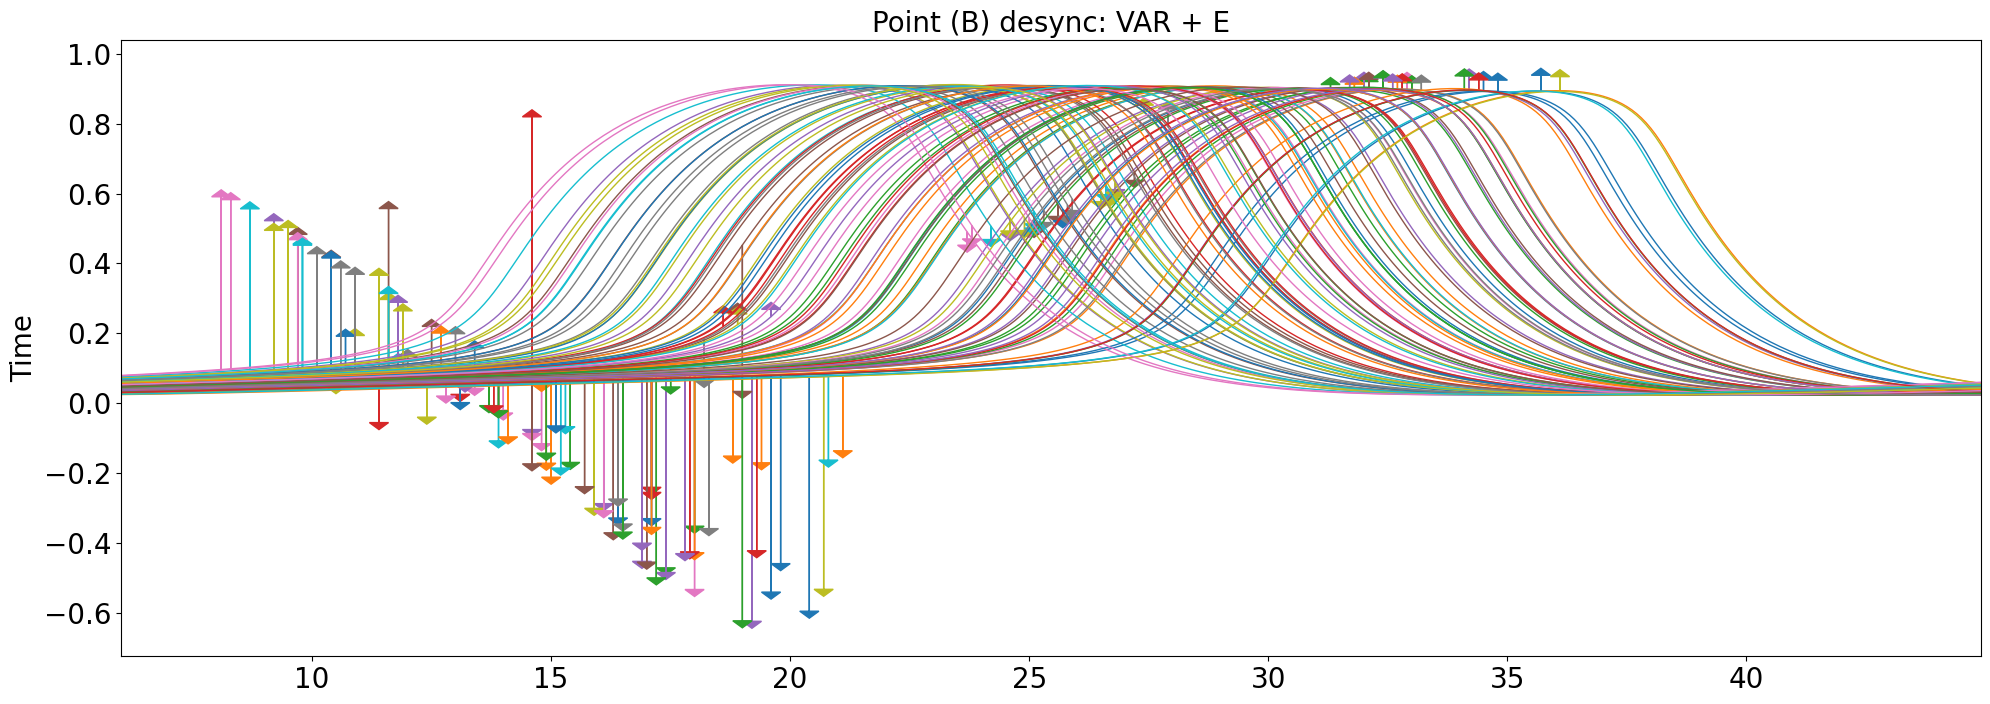

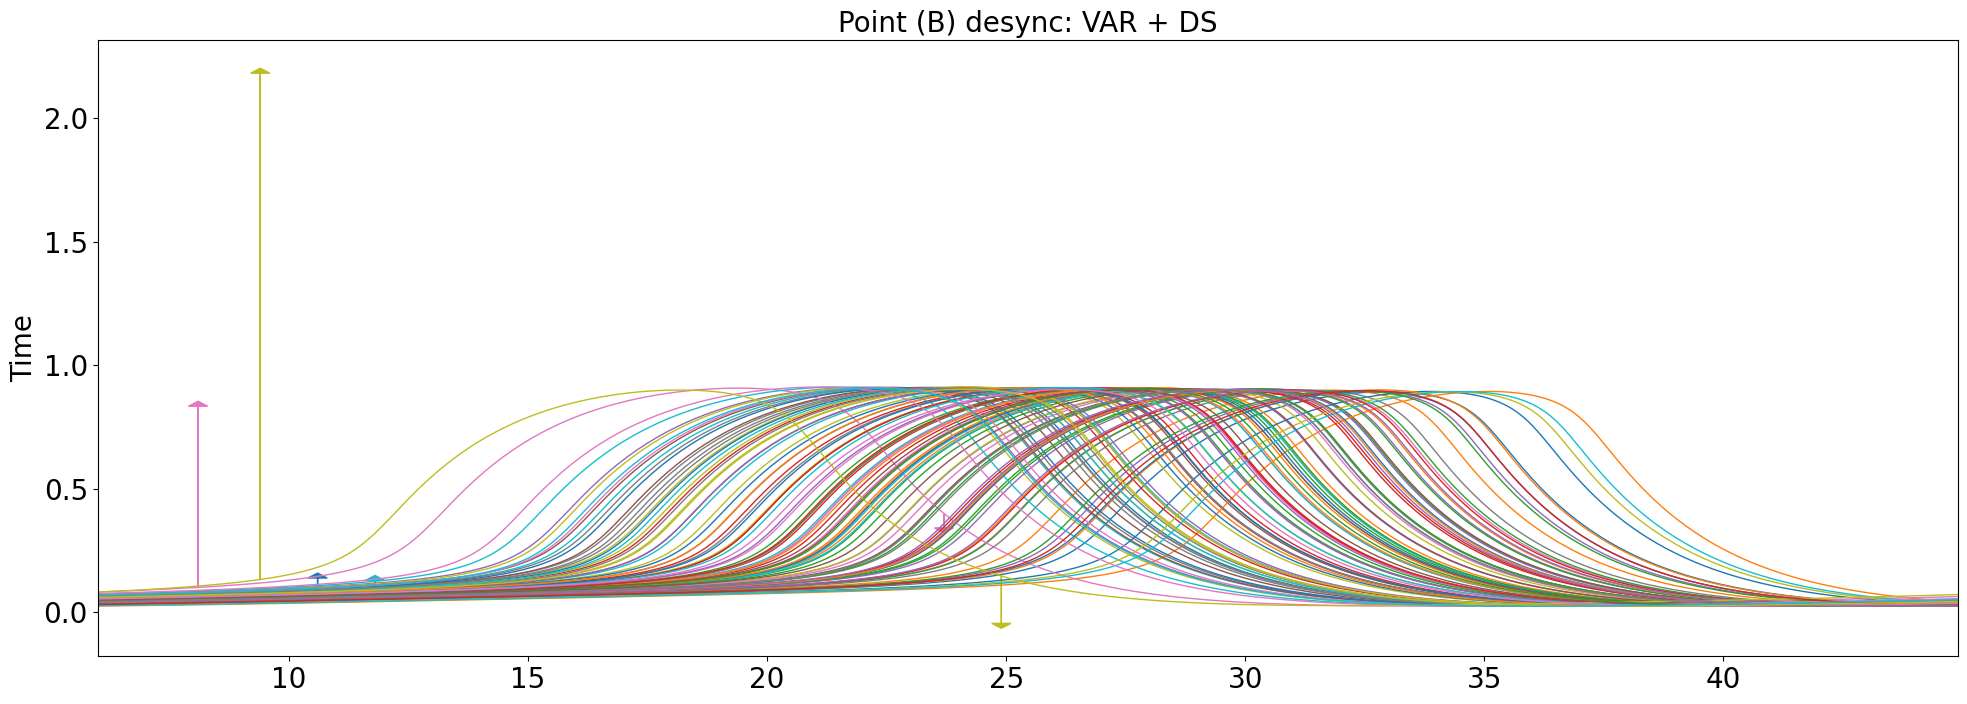

In [79]:
wi = 0
time = np.arange(i0*dt, i1*dt, dt)
lim = 1. * 1e-3

fig = plt.figure(figsize=(24,8))
ax = fig.add_subplot(111)

for n in range(N):
    if n%1 == 0:
        line = ax.plot(time, d0_var_L2["state"][wi][n,0,i0:i1])
        col = line[0].get_color()

        peaktime_array = scipy.signal.find_peaks(d0_var_L2["control"][wi][n,0,i0:i1])[0]
        peaktime = peaktime_array[np.argmax(d0_var_L2["control"][wi][n,0,i0+peaktime_array])]
        if np.abs(d0_var_L2["control"][wi][n,0,i0+peaktime]) > lim:
            plt.arrow((i0+peaktime)*dt, d0_var_L2["state"][wi][n,0,i0+peaktime], 0, 20*d0_var_L2["control"][wi][n,0,i0+peaktime], head_width=0.4, head_length=0.02, length_includes_head=False, color=col)
        peaktime_array = scipy.signal.find_peaks(-d0_var_L2["control"][wi][n,0,i0:i1])[0]
        peaktime = peaktime_array[np.argmax(-d0_var_L2["control"][wi][n,0,i0+peaktime_array])]
        if np.abs(d0_var_L2["control"][wi][n,0,i0+peaktime]) > lim:
            plt.arrow((i0+peaktime)*dt, d0_var_L2["state"][wi][n,0,i0+peaktime], 0, 20*d0_var_L2["control"][wi][n,0,i0+peaktime], head_width=0.4, head_length=0.02, length_includes_head=False, color=col)

ax.set_xlim(i0*dt, (i1-1)*dt)

ax.set_title("Point (B) desync: VAR + E")
ax.set_ylabel("Activity")
ax.set_ylabel("Time")
plt.savefig(os.path.join(datadir, "phases_B_VAR_E.jpg"), bbox_inches='tight', dpi=300)

plt.show()

fig = plt.figure(figsize=(24,8))
ax = fig.add_subplot(111)

for n in range(N):
    if n%1 == 0:
        line = ax.plot(time, d0_var_L1["state"][wi][n,0,i0:i1])
        col = line[0].get_color()

        peaktime_array = scipy.signal.find_peaks(d0_var_L1["control"][wi][n,0,i0:i1])[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(d0_var_L1["control"][wi][n,0,i0+peaktime_array])]
            if np.abs(d0_var_L1["control"][wi][n,0,i0+peaktime]) > lim:
                plt.arrow((i0+peaktime)*dt, d0_var_L1["state"][wi][n,0,i0+peaktime], 0, 20*d0_var_L1["control"][wi][n,0,i0+peaktime], head_width=0.4, head_length=0.02, length_includes_head=False, color=col)
            peaktime_array = scipy.signal.find_peaks(-d0_var_L1["control"][wi][n,0,i0:i1])[0]
            peaktime = peaktime_array[np.argmax(-d0_var_L1["control"][wi][n,0,i0+peaktime_array])]
            if np.abs(d0_var_L1["control"][wi][n,0,i0+peaktime]) > lim:
                plt.arrow((i0+peaktime)*dt, d0_var_L1["state"][wi][n,0,i0+peaktime], 0, 20*d0_var_L1["control"][wi][n,0,i0+peaktime], head_width=0.4, head_length=0.02, length_includes_head=False, color=col)

ax.set_xlim(i0*dt, (i1-1)*dt)

ax.set_title("Point (B) desync: VAR + DS")
ax.set_ylabel("Activity")
ax.set_ylabel("Time")
plt.savefig(os.path.join(datadir, "phases_B_VAR_DS.jpg"), bbox_inches='tight', dpi=300)
plt.show()

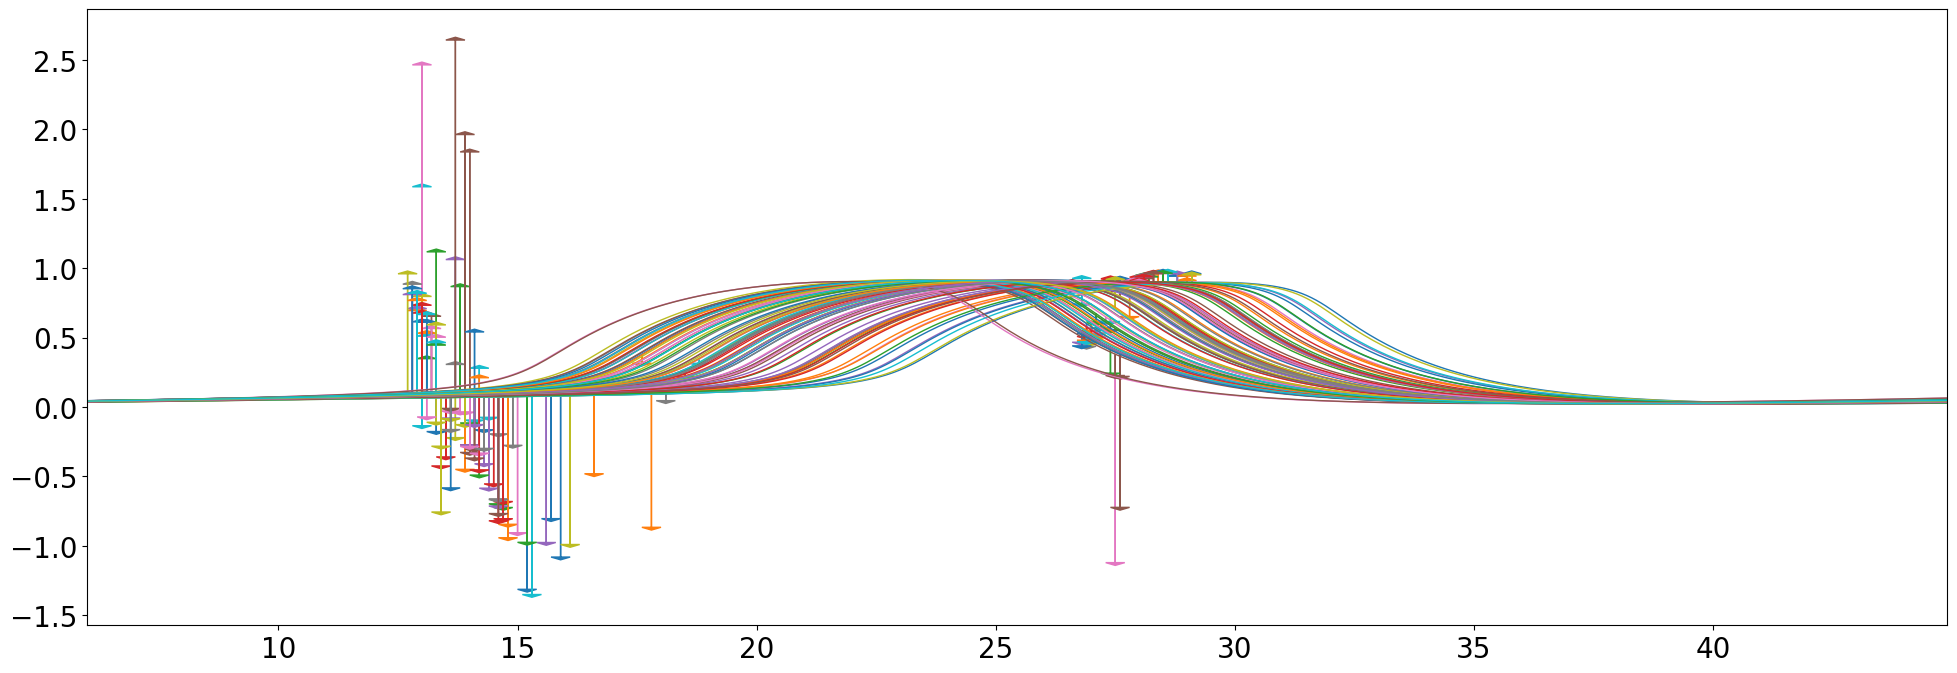

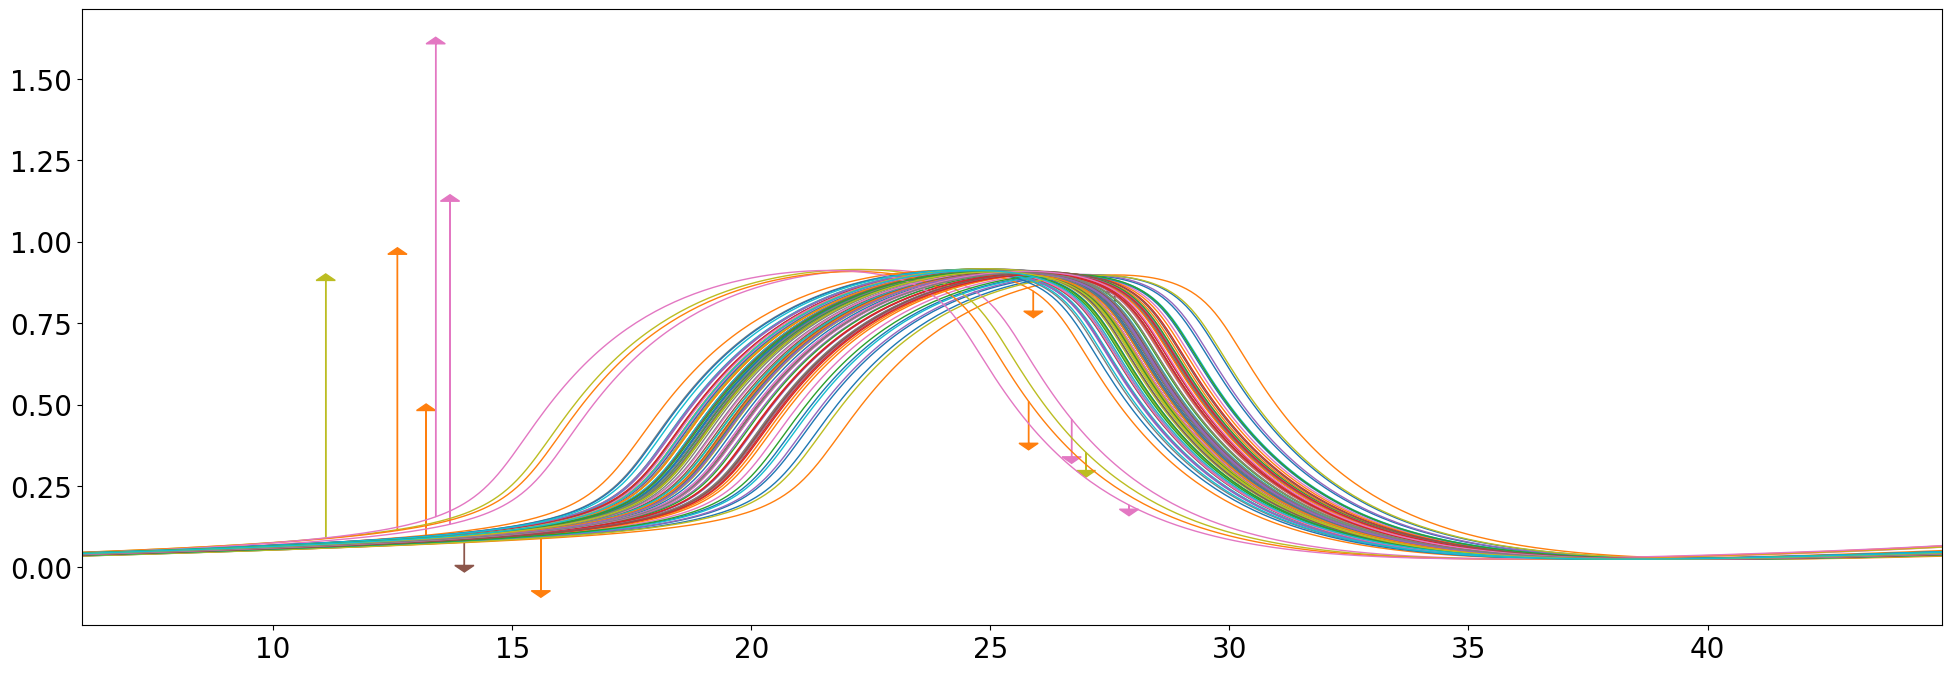

In [56]:
i0, i1 = 60, 450
time = np.arange(i0*dt, i1*dt, dt)
lim = 1e-3

wi = 1

fig = plt.figure(figsize=(24,8))
ax = fig.add_subplot(111)

for n in range(N):
    if n%1 == 0:
        line = ax.plot(time, d2_var_L2["state"][wi][n,0,i0:i1])
        col = line[0].get_color()

        peaktime_array = scipy.signal.find_peaks(d2_var_L2["control"][wi][n,0,i0:i1])[0]
        peaktime = peaktime_array[np.argmax(d2_var_L2["control"][wi][n,0,i0+peaktime_array])]
        if np.abs(d2_var_L2["control"][wi][n,0,i0+peaktime]) > lim:
            plt.arrow((i0+peaktime)*dt, d2_var_L2["state"][wi][n,0,i0+peaktime], 0, 20*d2_var_L2["control"][wi][n,0,i0+peaktime], head_width=0.4, head_length=0.02, length_includes_head=False, color=col)
        peaktime_array = scipy.signal.find_peaks(-d2_var_L2["control"][wi][n,0,i0:i1])[0]
        peaktime = peaktime_array[np.argmax(-d2_var_L2["control"][wi][n,0,i0+peaktime_array])]
        if np.abs(d2_var_L2["control"][wi][n,0,i0+peaktime]) > lim:
            plt.arrow((i0+peaktime)*dt, d2_var_L2["state"][wi][n,0,i0+peaktime], 0, 20*d2_var_L2["control"][wi][n,0,i0+peaktime], head_width=0.4, head_length=0.02, length_includes_head=False, color=col)

ax.set_xlim(i0*dt, (i1-1)*dt)
plt.show()

fig = plt.figure(figsize=(24,8))
ax = fig.add_subplot(111)

for n in range(N):
    if n%1 == 0:
        line = ax.plot(time, d2_var_L1["state"][wi][n,0,i0:i1])
        col = line[0].get_color()

        peaktime_array = scipy.signal.find_peaks(d2_var_L1["control"][wi][n,0,i0:i1])[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(d2_var_L1["control"][wi][n,0,i0+peaktime_array])]
            if np.abs(d2_var_L1["control"][wi][n,0,i0+peaktime]) > lim:
                plt.arrow((i0+peaktime)*dt, d2_var_L1["state"][wi][n,0,i0+peaktime], 0, 10*d2_var_L1["control"][wi][n,0,i0+peaktime], head_width=0.4, head_length=0.02, length_includes_head=False, color=col)
            peaktime_array = scipy.signal.find_peaks(-d2_var_L1["control"][wi][n,0,i0:i1])[0]
            peaktime = peaktime_array[np.argmax(-d2_var_L1["control"][wi][n,0,i0+peaktime_array])]
            if np.abs(d2_var_L1["control"][wi][n,0,i0+peaktime]) > lim:
                plt.arrow((i0+peaktime)*dt, d2_var_L1["state"][wi][n,0,i0+peaktime], 0, 10*d2_var_L1["control"][wi][n,0,i0+peaktime], head_width=0.4, head_length=0.02, length_includes_head=False, color=col)

ax.set_xlim(i0*dt, (i1-1)*dt)
plt.show()

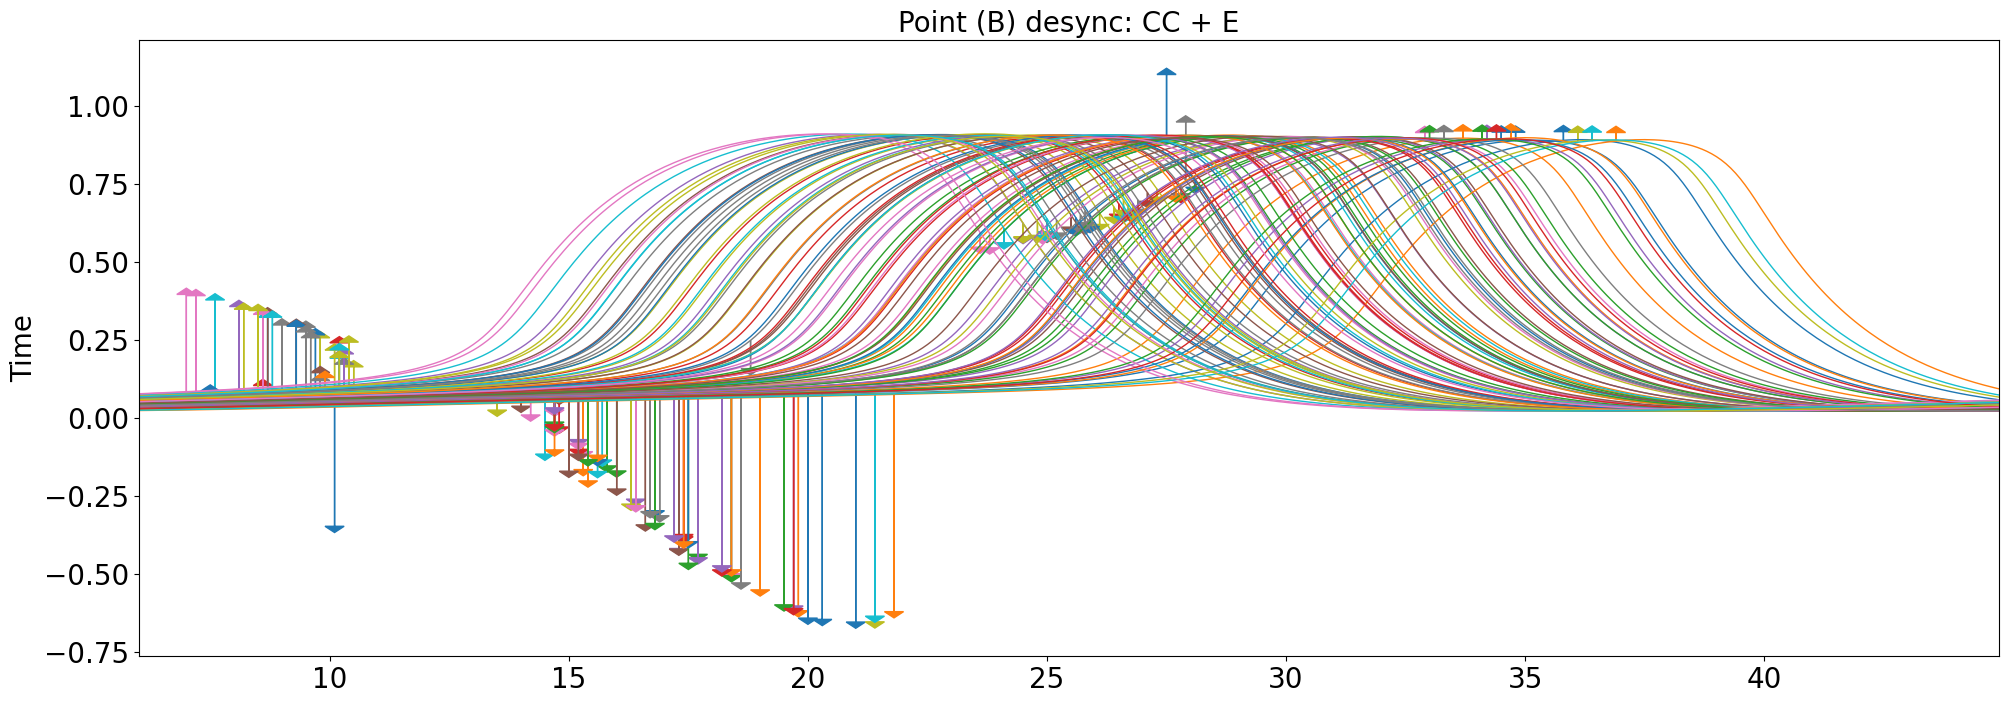

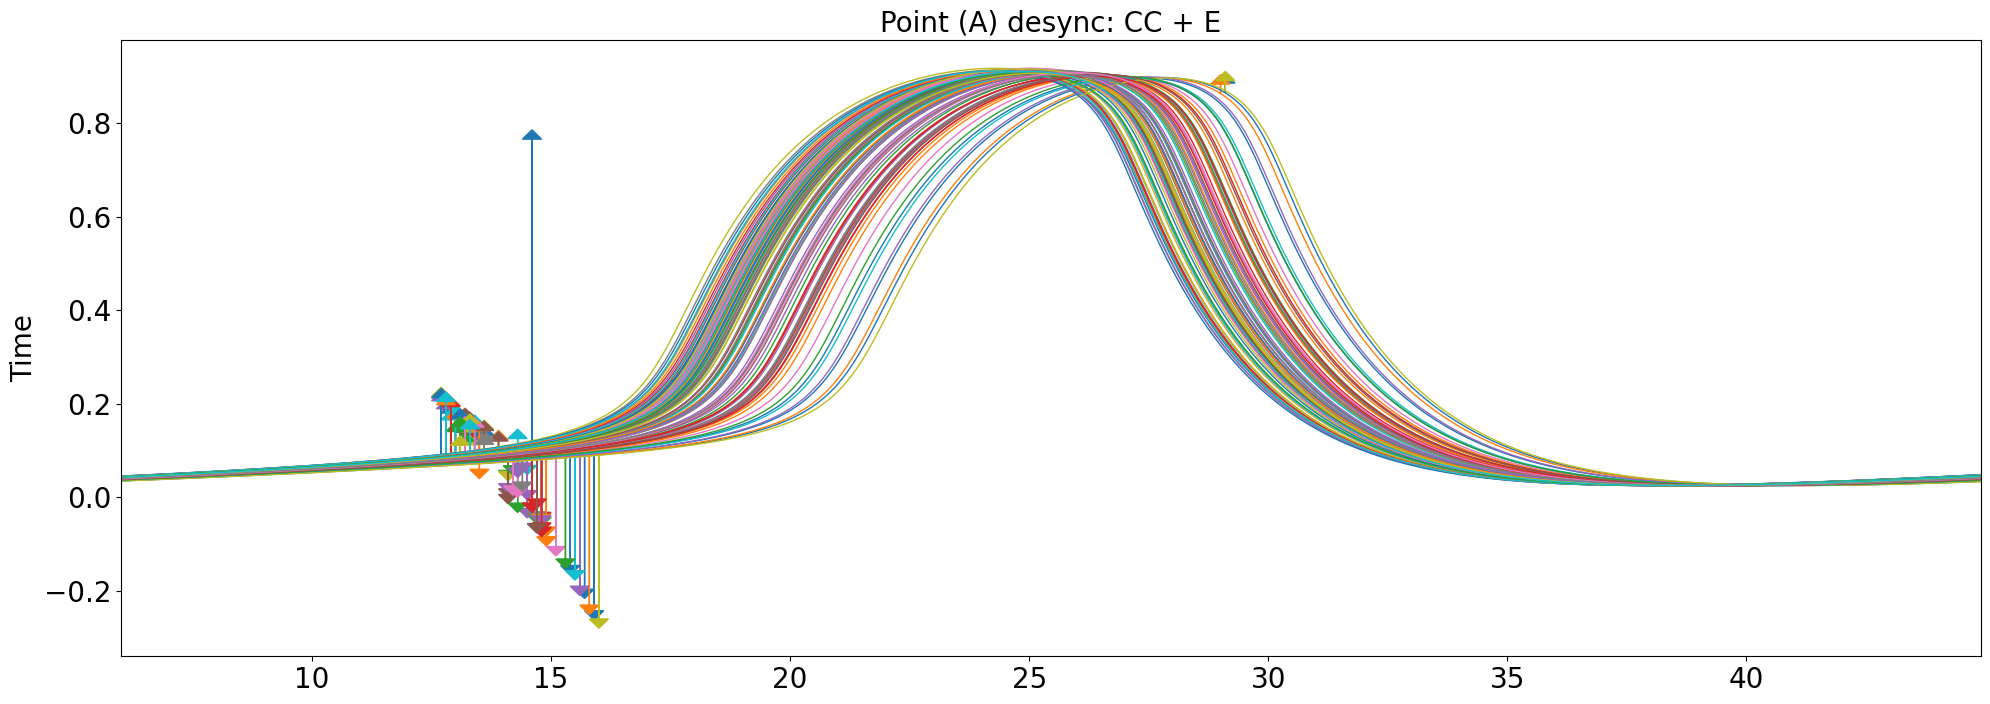

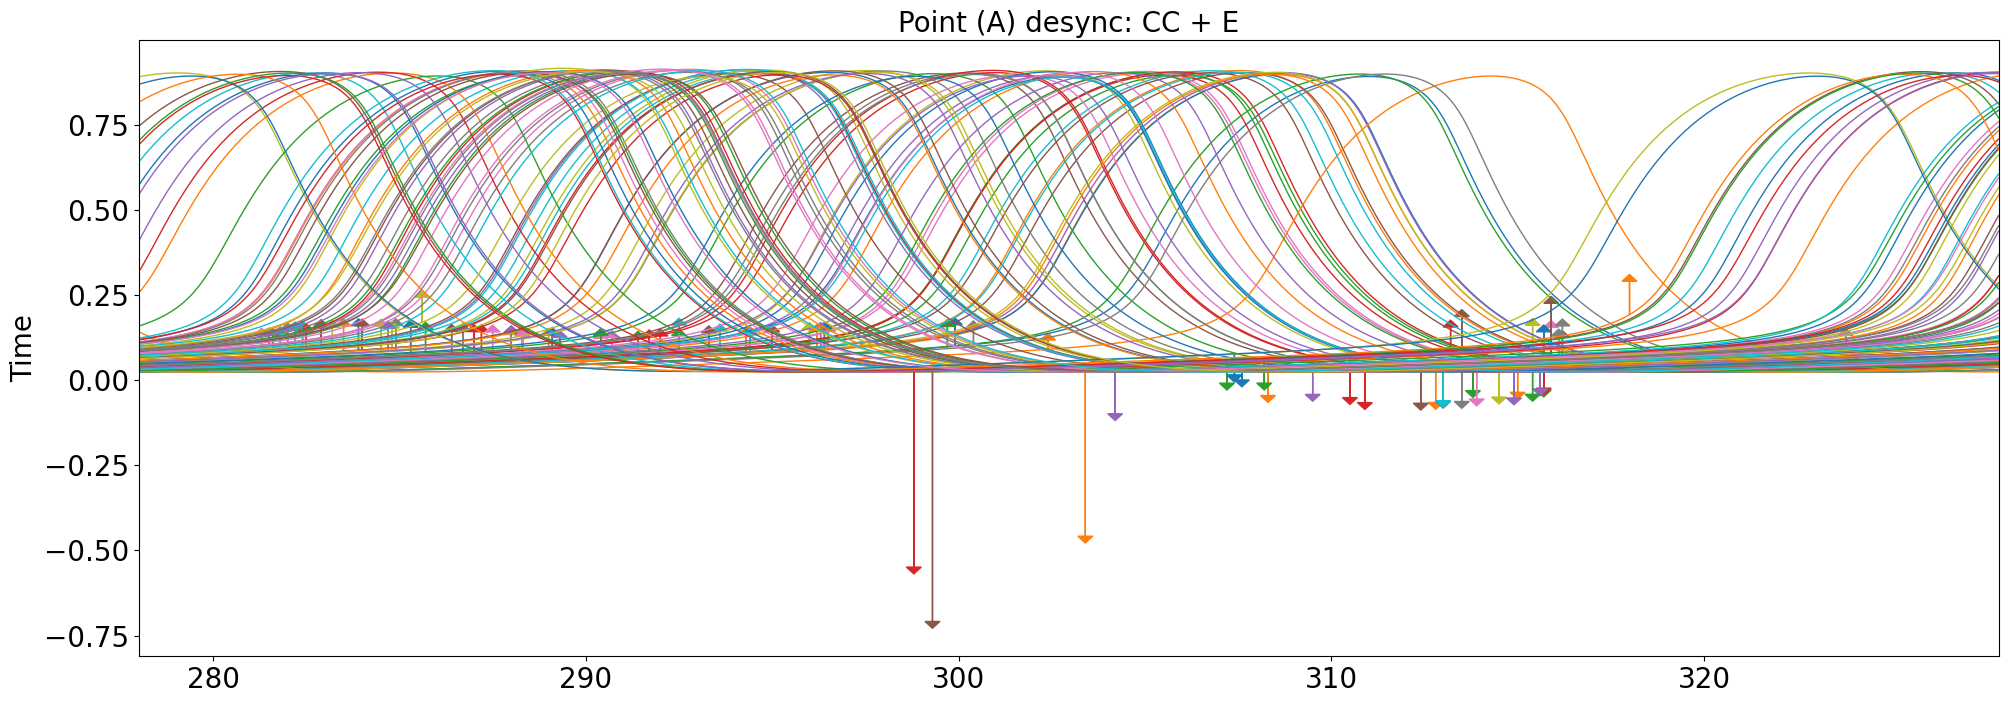

In [146]:
wi = 0
time = np.arange(i0*dt, i1*dt, dt)
lim = 1. * 1e-3

fig = plt.figure(figsize=(24,8))
ax = fig.add_subplot(111)

for n in range(N):
    if n%1 == 0:
        line = ax.plot(time, d0_cc_L2["state"][wi][n,0,i0:i1])
        col = line[0].get_color()

        peaktime_array = scipy.signal.find_peaks(d0_cc_L2["control"][wi][n,0,i0:i1])[0]
        peaktime = peaktime_array[np.argmax(d0_cc_L2["control"][wi][n,0,i0+peaktime_array])]
        if np.abs(d0_cc_L2["control"][wi][n,0,i0+peaktime]) > lim:
            plt.arrow((i0+peaktime)*dt, d0_cc_L2["state"][wi][n,0,i0+peaktime], 0, 20*d0_cc_L2["control"][wi][n,0,i0+peaktime], head_width=0.4, head_length=0.02, length_includes_head=False, color=col)
        peaktime_array = scipy.signal.find_peaks(-d0_cc_L2["control"][wi][n,0,i0:i1])[0]
        peaktime = peaktime_array[np.argmax(-d0_cc_L2["control"][wi][n,0,i0+peaktime_array])]
        if np.abs(d0_cc_L2["control"][wi][n,0,i0+peaktime]) > lim:
            plt.arrow((i0+peaktime)*dt, d0_cc_L2["state"][wi][n,0,i0+peaktime], 0, 20*d0_cc_L2["control"][wi][n,0,i0+peaktime], head_width=0.4, head_length=0.02, length_includes_head=False, color=col)

ax.set_xlim(i0*dt, (i1-1)*dt)

ax.set_title("Point (B) desync: CC + E")
ax.set_ylabel("Activity")
ax.set_ylabel("Time")
plt.savefig(os.path.join(datadir, "phases_B_CC_E.jpg"), bbox_inches='tight', dpi=300)

plt.show()


fig = plt.figure(figsize=(24,8))
ax = fig.add_subplot(111)

for n in range(N):
    if n%1 == 0:
        line = ax.plot(time, d2_cc_L2["state"][wi][n,0,i0:i1])
        col = line[0].get_color()

        peaktime_array = scipy.signal.find_peaks(d2_cc_L2["control"][wi][n,0,i0:i1])[0]
        peaktime = peaktime_array[np.argmax(d2_cc_L2["control"][wi][n,0,i0+peaktime_array])]
        if np.abs(d2_cc_L2["control"][wi][n,0,i0+peaktime]) > lim:
            plt.arrow((i0+peaktime)*dt, d2_cc_L2["state"][wi][n,0,i0+peaktime], 0, 20*d2_cc_L2["control"][wi][n,0,i0+peaktime], head_width=0.4, head_length=0.02, length_includes_head=False, color=col)
        peaktime_array = scipy.signal.find_peaks(-d2_cc_L2["control"][wi][n,0,i0:i1])[0]
        peaktime = peaktime_array[np.argmax(-d2_cc_L2["control"][wi][n,0,i0+peaktime_array])]
        if np.abs(d2_cc_L2["control"][wi][n,0,i0+peaktime]) > lim:
            plt.arrow((i0+peaktime)*dt, d2_cc_L2["state"][wi][n,0,i0+peaktime], 0, 20*d2_cc_L2["control"][wi][n,0,i0+peaktime], head_width=0.4, head_length=0.02, length_includes_head=False, color=col)

ax.set_xlim(i0*dt, (i1-1)*dt)

ax.set_title("Point (A) desync: CC + E")
ax.set_ylabel("Activity")
ax.set_ylabel("Time")
plt.savefig(os.path.join(datadir, "phases_A_CC_E.jpg"), bbox_inches='tight', dpi=300)

plt.show()

fig = plt.figure(figsize=(24,8))
ax = fig.add_subplot(111)

time = np.arange(i0a*dt, i1a*dt, dt)


for n in range(N):
    if n%1 == 0:
        line = ax.plot(time, d1_cc_L2["state"][wi][n,0,i0a:i1a])
        col = line[0].get_color()

        peaktime_array = scipy.signal.find_peaks(d1_cc_L2["control"][wi][n,0,i0a:i1a])[0]
        peaktime = peaktime_array[np.argmax(d1_cc_L2["control"][wi][n,0,i0a+peaktime_array])]
        if np.abs(d1_cc_L2["control"][wi][n,0,i0a+peaktime]) > lim:
            plt.arrow((i0a+peaktime)*dt, d1_cc_L2["state"][wi][n,0,i0a+peaktime], 0, 20*d1_cc_L2["control"][wi][n,0,i0a+peaktime], head_width=0.4, head_length=0.02, length_includes_head=False, color=col)
        peaktime_array = scipy.signal.find_peaks(-d1_cc_L2["control"][wi][n,0,i0a:i1a])[0]
        peaktime = peaktime_array[np.argmax(-d1_cc_L2["control"][wi][n,0,i0a+peaktime_array])]
        if np.abs(d1_cc_L2["control"][wi][n,0,i0a+peaktime]) > lim:
            plt.arrow((i0a+peaktime)*dt, d1_cc_L2["state"][wi][n,0,i0a+peaktime], 0, 20*d1_cc_L2["control"][wi][n,0,i0a+peaktime], head_width=0.4, head_length=0.02, length_includes_head=False, color=col)

ax.set_xlim(i0a*dt, (i1a-1)*dt)

ax.set_title("Point (A) desync: CC + E")
ax.set_ylabel("Activity")
ax.set_ylabel("Time")
plt.savefig(os.path.join(datadir, "phases_A_CC_E.jpg"), bbox_inches='tight', dpi=300)

plt.show()

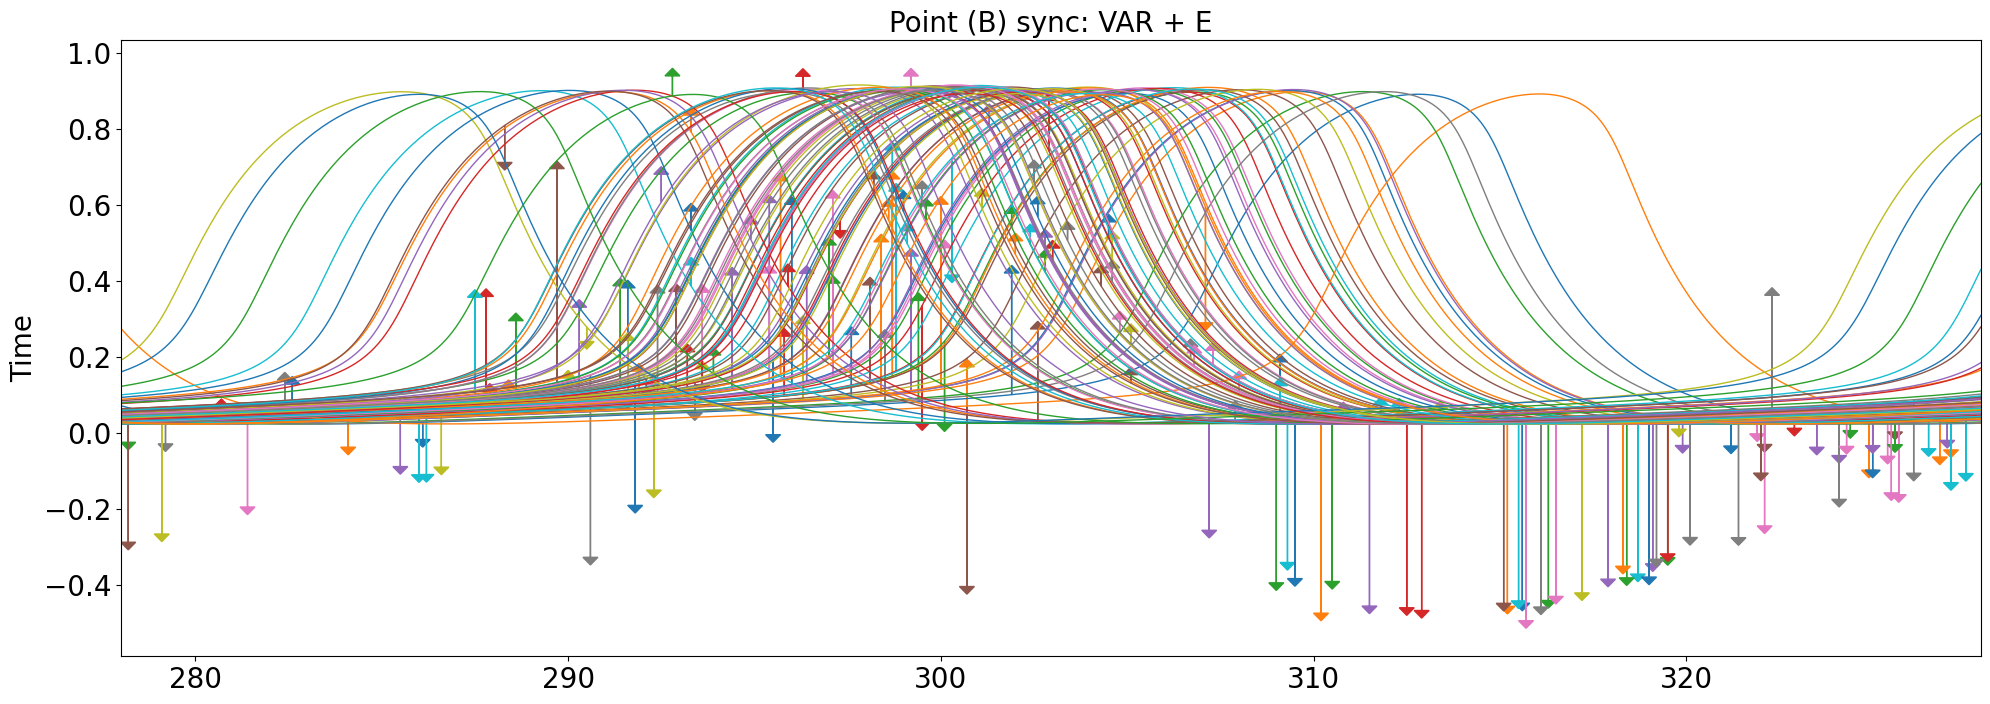

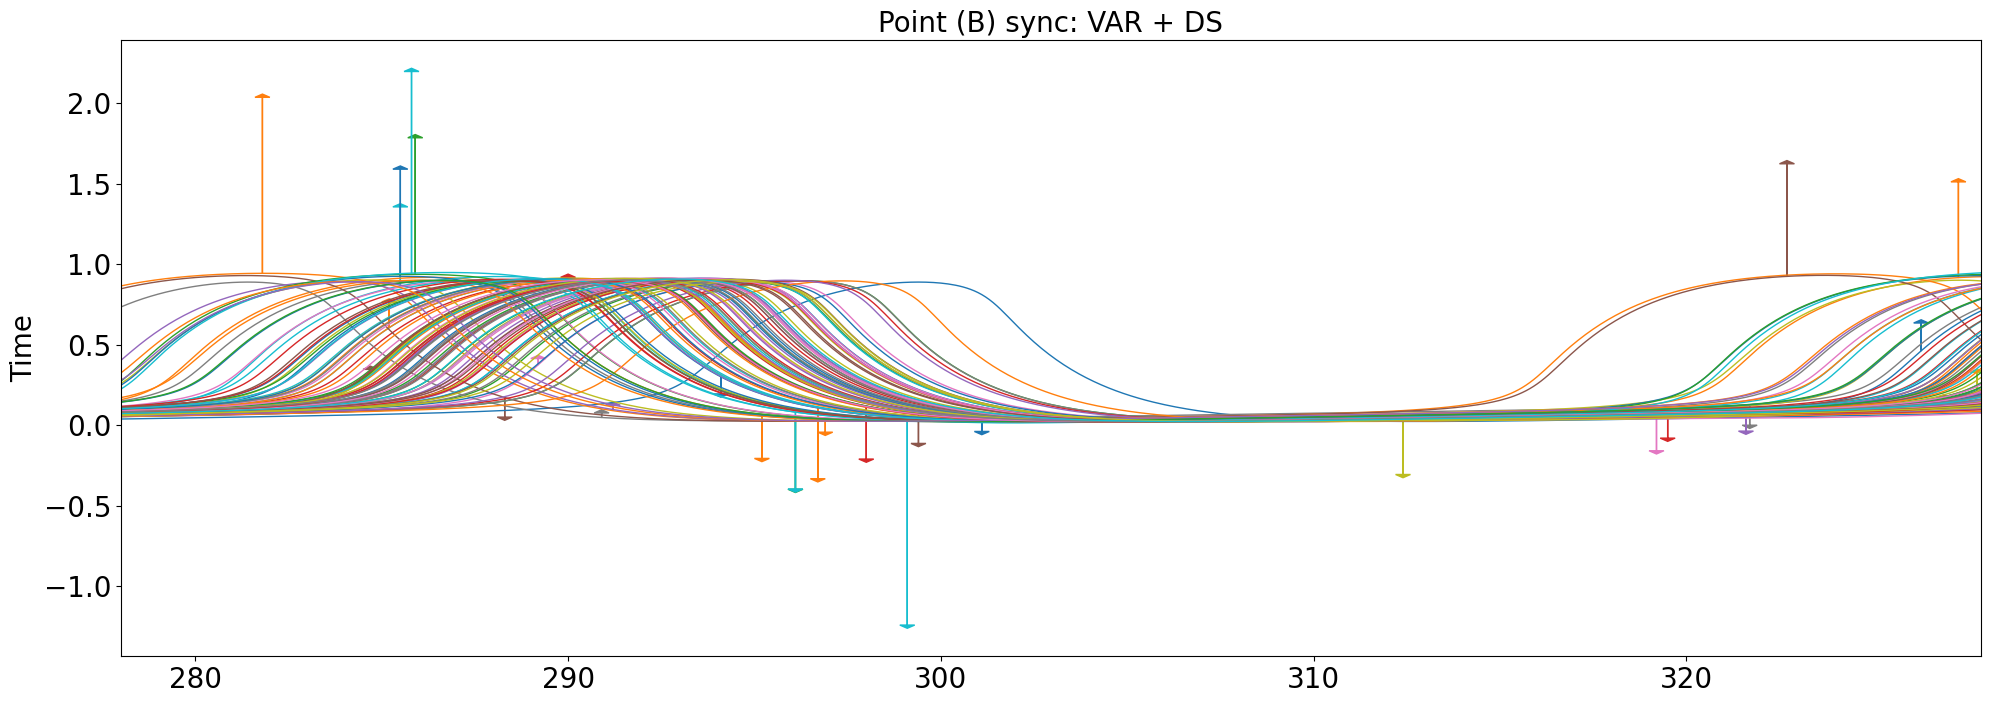

In [116]:
wi = 1
lim = 2. * 1e-3

timea = np.arange(i0a*dt, i1a*dt, dt)

fig = plt.figure(figsize=(24,8))
ax = fig.add_subplot(111)

for n in range(N):
    if n%1==0:
        line = ax.plot(timea, d1_var_L2["state"][wi][n,0,i0a:i1a])
        col = line[0].get_color()

        peaktime_array = scipy.signal.find_peaks(d1_var_L2["control"][wi][n,0,i0a:i1a])[0]
        peaktime = peaktime_array[np.argmax(d1_var_L2["control"][wi][n,0,i0a+peaktime_array])]
        if np.abs(d1_var_L2["control"][wi][n,0,i0a+peaktime]) > lim:
            plt.arrow((i0a+peaktime)*dt, d1_var_L2["state"][wi][n,0,i0a+peaktime], 0, 10*d1_var_L2["control"][wi][n,0,i0a+peaktime], head_width=0.4, head_length=0.02, length_includes_head=False, color=col)
        peaktime_array = scipy.signal.find_peaks(-d1_var_L2["control"][wi][n,0,i0a:i1a])[0]
        peaktime = peaktime_array[np.argmax(-d1_var_L2["control"][wi][n,0,i0a+peaktime_array])]
        if np.abs(d1_var_L2["control"][wi][n,0,i0a+peaktime]) > lim:
            arrowlength = max(10*d1_var_L2["control"][wi][n,0,i0a+peaktime], -0.6)
            plt.arrow((i0a+peaktime)*dt, d1_var_L2["state"][wi][n,0,i0a+peaktime], 0, arrowlength, head_width=0.4, head_length=0.02, length_includes_head=False, color=col)

ax.set_xlim(i0a*dt, (i1a-1)*dt)

ax.set_title("Point (B) sync: VAR + E")
ax.set_ylabel("Activity")
ax.set_ylabel("Time")
plt.savefig(os.path.join(datadir, "phases_B_sync_VAR_E.jpg"), bbox_inches='tight', dpi=300)

plt.show()

if True:
    fig = plt.figure(figsize=(24,8))
    ax = fig.add_subplot(111)

    for n in range(N):
        if n%1 == 0:
            line = ax.plot(timea, d1_var_L1["state"][wi][n,0,i0a:i1a])
            col = line[0].get_color()

            peaktime_array = scipy.signal.find_peaks(d1_var_L1["control"][wi][n,0,i0a:i1a])[0]
            peaktime = peaktime_array[np.argmax(d1_var_L1["control"][wi][n,0,i0a+peaktime_array])]
            if np.abs(d1_var_L1["control"][wi][n,0,i0a+peaktime]) > lim:
                plt.arrow((i0a+peaktime)*dt, d1_var_L1["state"][wi][n,0,i0a+peaktime], 0, 1*d1_var_L1["control"][wi][n,0,i0a+peaktime], head_width=0.4, head_length=0.02, length_includes_head=False, color=col)
            peaktime_array = scipy.signal.find_peaks(-d1_var_L1["control"][wi][n,0,i0a:i1a])[0]
            peaktime = peaktime_array[np.argmax(-d1_var_L1["control"][wi][n,0,i0a+peaktime_array])]
            if np.abs(d1_var_L1["control"][wi][n,0,i0a+peaktime]) > lim:
                plt.arrow((i0a+peaktime)*dt, d1_var_L1["state"][wi][n,0,i0a+peaktime], 0, 1*d1_var_L1["control"][wi][n,0,i0a+peaktime], head_width=0.4, head_length=0.02, length_includes_head=False, color=col)

    ax.set_xlim(i0a*dt, (i1a-1)*dt)

    ax.set_title("Point (B) sync: VAR + DS")
    ax.set_ylabel("Activity")
    ax.set_ylabel("Time")
    plt.savefig(os.path.join(datadir, "phases_B_sync_VAR_DS.jpg"), bbox_inches='tight', dpi=300)
    plt.show()


/tmp/ipykernel_2759375/1609539322.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colmap = mpl.cm.get_cmap('jet')


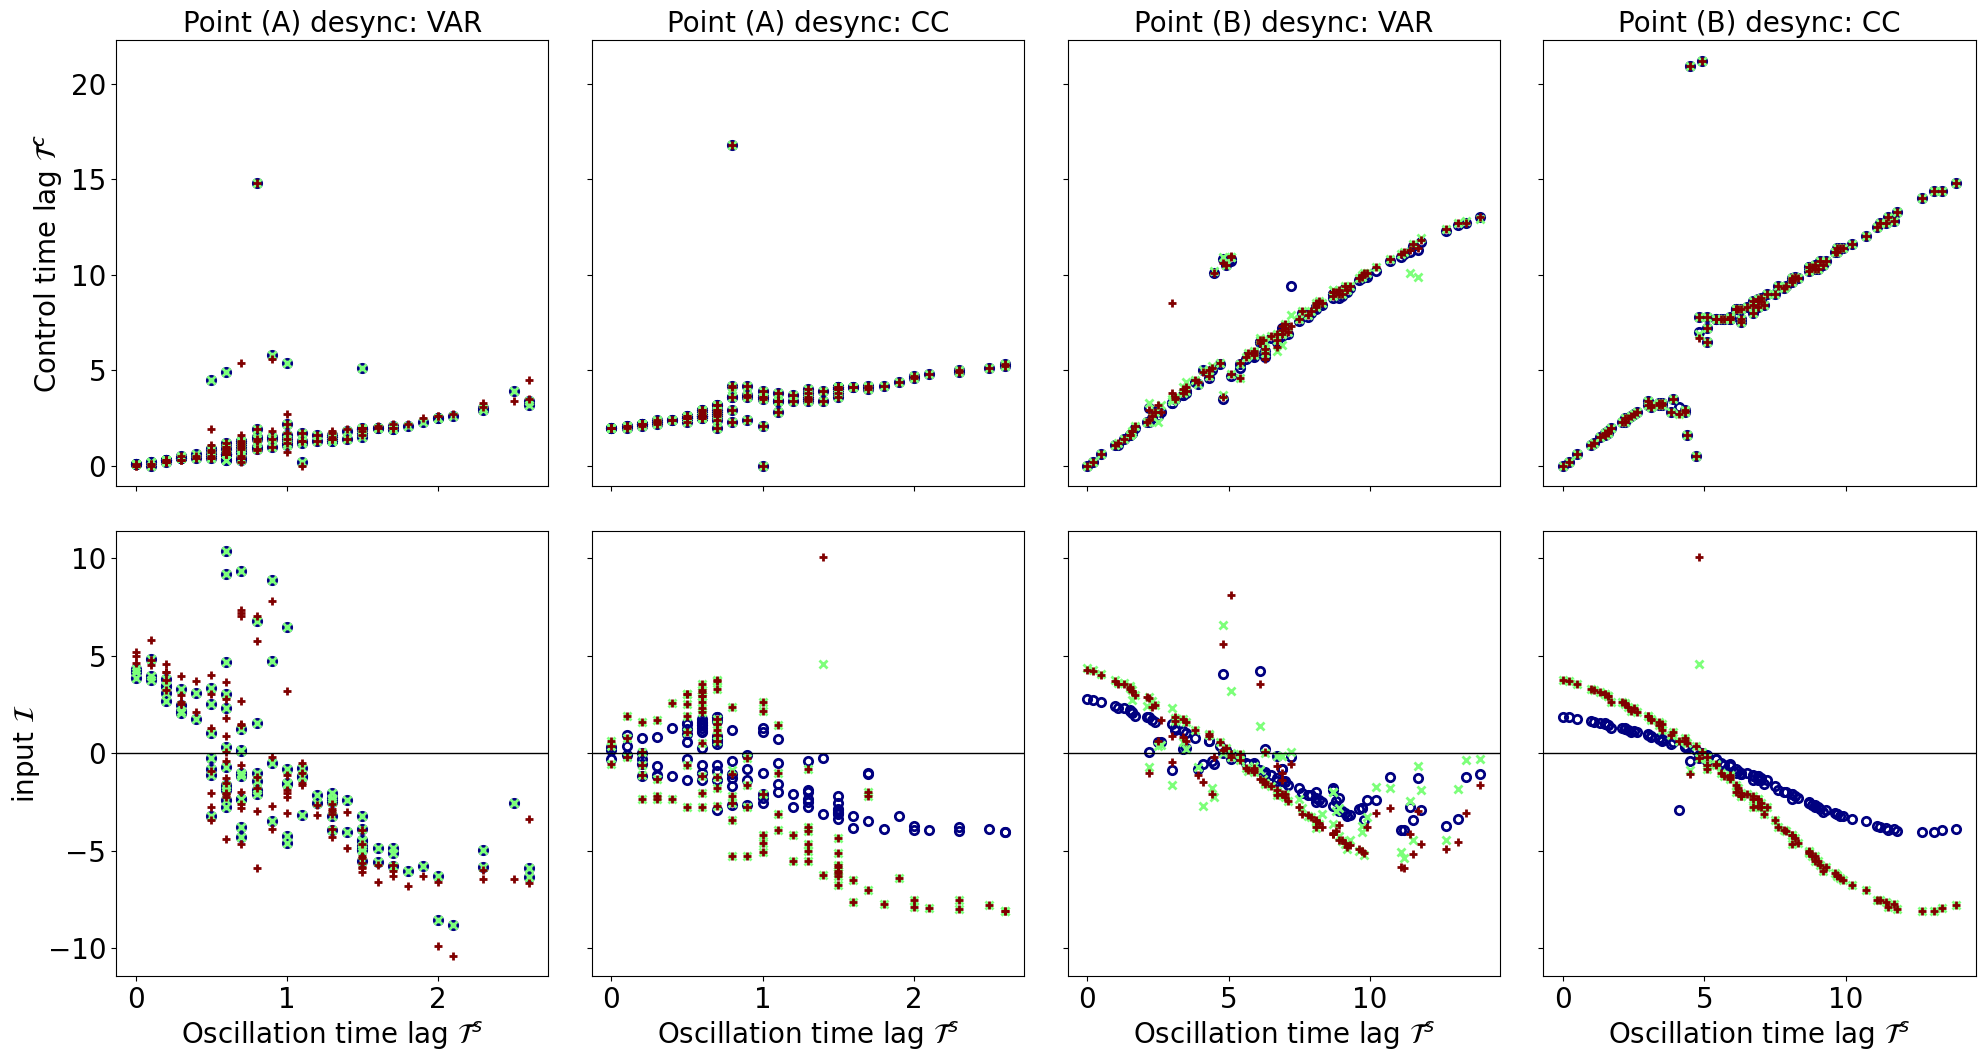

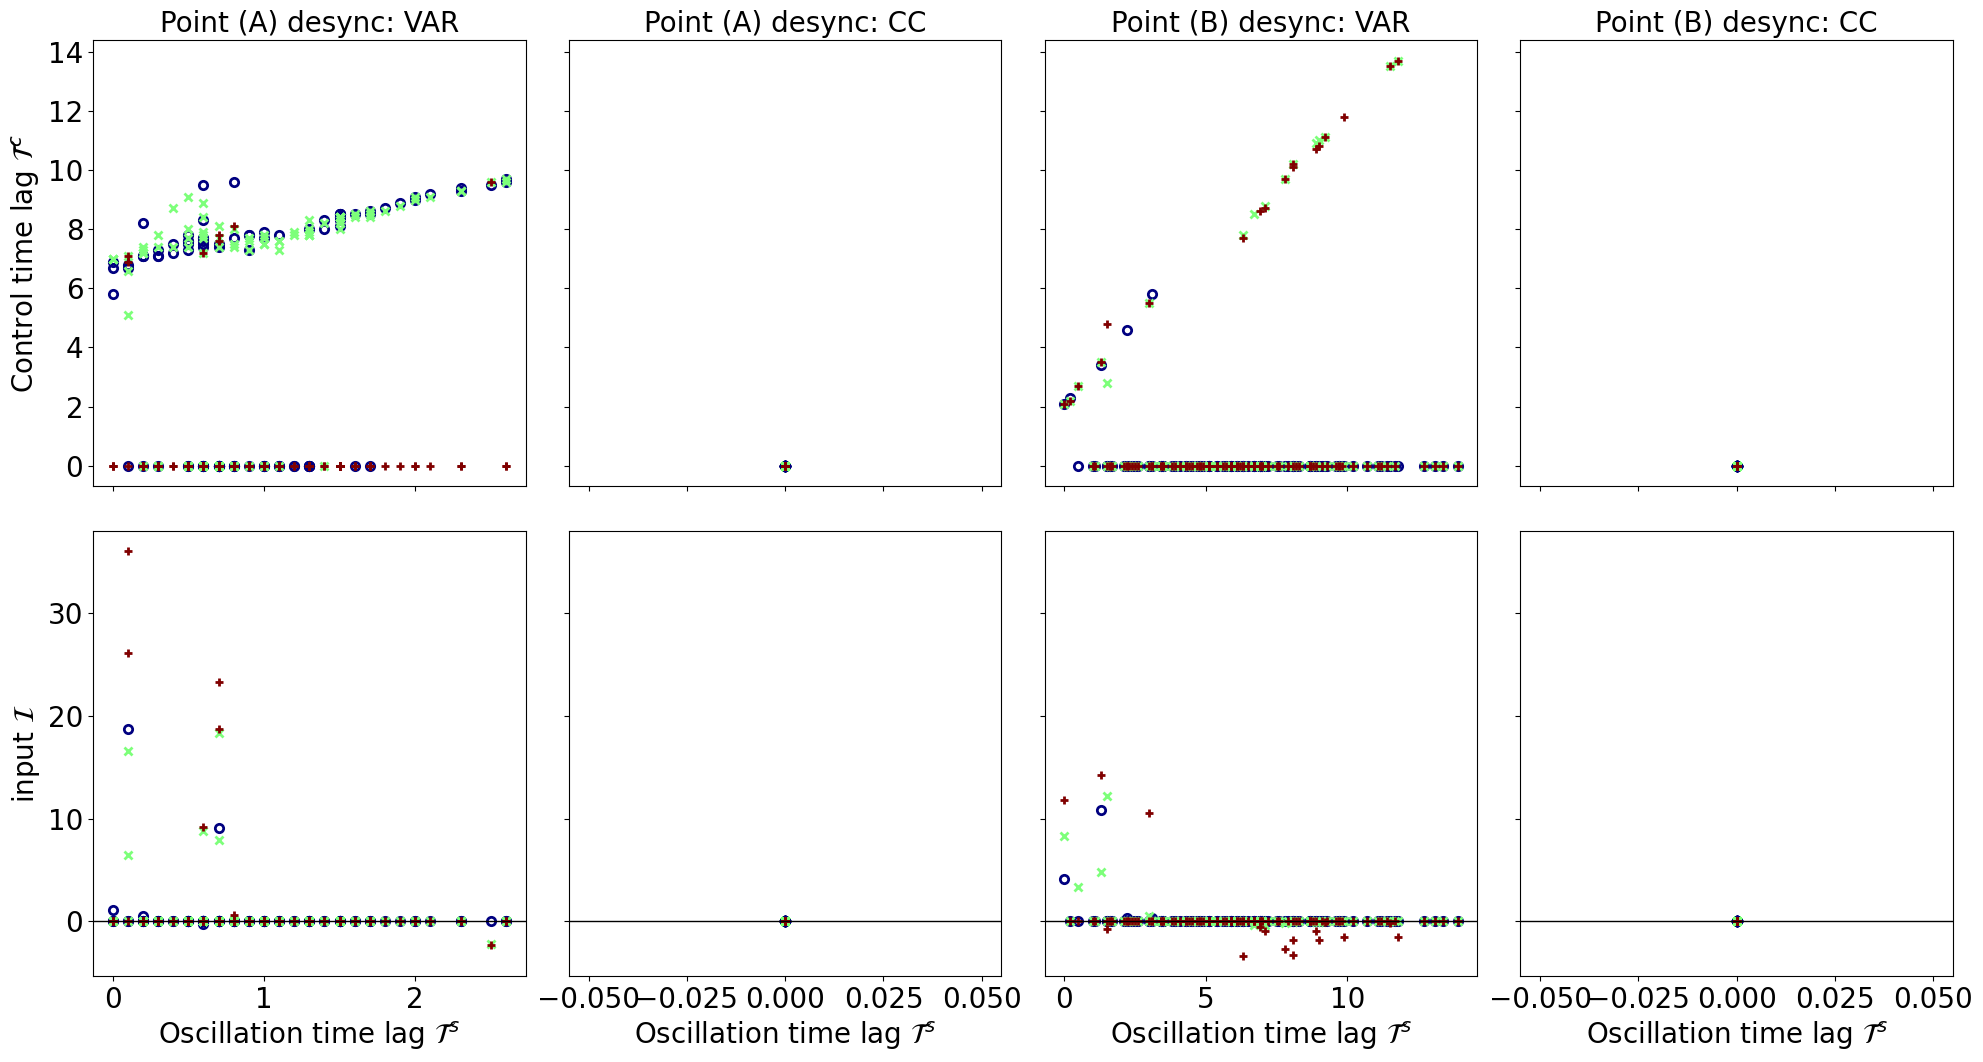

In [152]:
xlabel = r"Oscillation time lag $\mathcal{T}^s$"
ylabel = [r"Control time lag $\mathcal{T}^c$", r"input $\mathcal{I}$"]
titles = ["Point (A) desync: VAR", "Point (A) desync: CC", "Point (B) desync: VAR", "Point (B) desync: CC"]

#### cost comb // point // weight // n

colmap = mpl.cm.get_cmap('jet')
marker= ["o", "x", "+"]

x_array = peak_times[0,:]
y_array = [control_times, input]

fig, ax = plt.subplots(len(y_array), 4, figsize=(24,12), sharey="row")

for wi in range(3):
    ax[0,0].plot(peak_times[0, 2, wi, :], control_times[0, 2, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")
    ax[1,0].plot(peak_times[0, 2, wi, :], input[0, 2, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")
    ax[0,2].plot(peak_times[0, 0, wi, :], control_times[0, 0, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")
    ax[1,2].plot(peak_times[0, 0, wi, :], input[0, 0, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")
    ax[0,1].plot(peak_times[2, 2, wi, :], control_times[2, 2, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")
    ax[1,1].plot(peak_times[2, 2, wi, :], input[2, 2, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")
    ax[0,3].plot(peak_times[2, 0, wi, :], control_times[2, 0, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")
    ax[1,3].plot(peak_times[2, 0, wi, :], input[2, 0, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")

ax[0,0].set_ylabel(ylabel[0])
ax[1,0].set_ylabel(ylabel[1])

for ix in range(4):
    ax[0,ix].set_xticklabels([])
    ax[0,ix].set_title(titles[ix])
    ax[1,ix].axhline(y=0, color='k')
    ax[1,ix].set_xlabel(xlabel)


plt.subplots_adjust(left=None, bottom=0.1, right=None, top=None, wspace=0.1, hspace=0.1)
plt.savefig(os.path.join(datadir, "times_input_all_L2.jpg"), bbox_inches='tight', dpi=300)
plt.show()

fig, ax = plt.subplots(len(y_array), 4, figsize=(24,12), sharey="row")

for wi in range(3):
    ax[0,0].plot(peak_times[1, 2, wi, :], control_times[1, 2, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")
    ax[1,0].plot(peak_times[1, 2, wi, :], input[1, 2, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")
    ax[0,2].plot(peak_times[1, 0, wi, :], control_times[1, 0, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")
    ax[1,2].plot(peak_times[1, 0, wi, :], input[1, 0, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")
    ax[0,1].plot(peak_times[3, 2, wi, :], control_times[3, 2, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")
    ax[1,1].plot(peak_times[3, 2, wi, :], input[3, 2, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")
    ax[0,3].plot(peak_times[3, 0, wi, :], control_times[3, 0, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")
    ax[1,3].plot(peak_times[3, 0, wi, :], input[3, 0, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")

ax[0,0].set_ylabel(ylabel[0])
ax[1,0].set_ylabel(ylabel[1])

for ix in range(4):
    ax[0,ix].set_xticklabels([])
    ax[0,ix].set_title(titles[ix])
    ax[1,ix].axhline(y=0, color='k')
    ax[1,ix].set_xlabel(xlabel)

plt.subplots_adjust(left=None, bottom=0.1, right=None, top=None, wspace=0.1, hspace=0.1)
plt.savefig(os.path.join(datadir, "times_input_all_L1.jpg"), bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_2759375/280943395.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colmap = mpl.cm.get_cmap('jet')


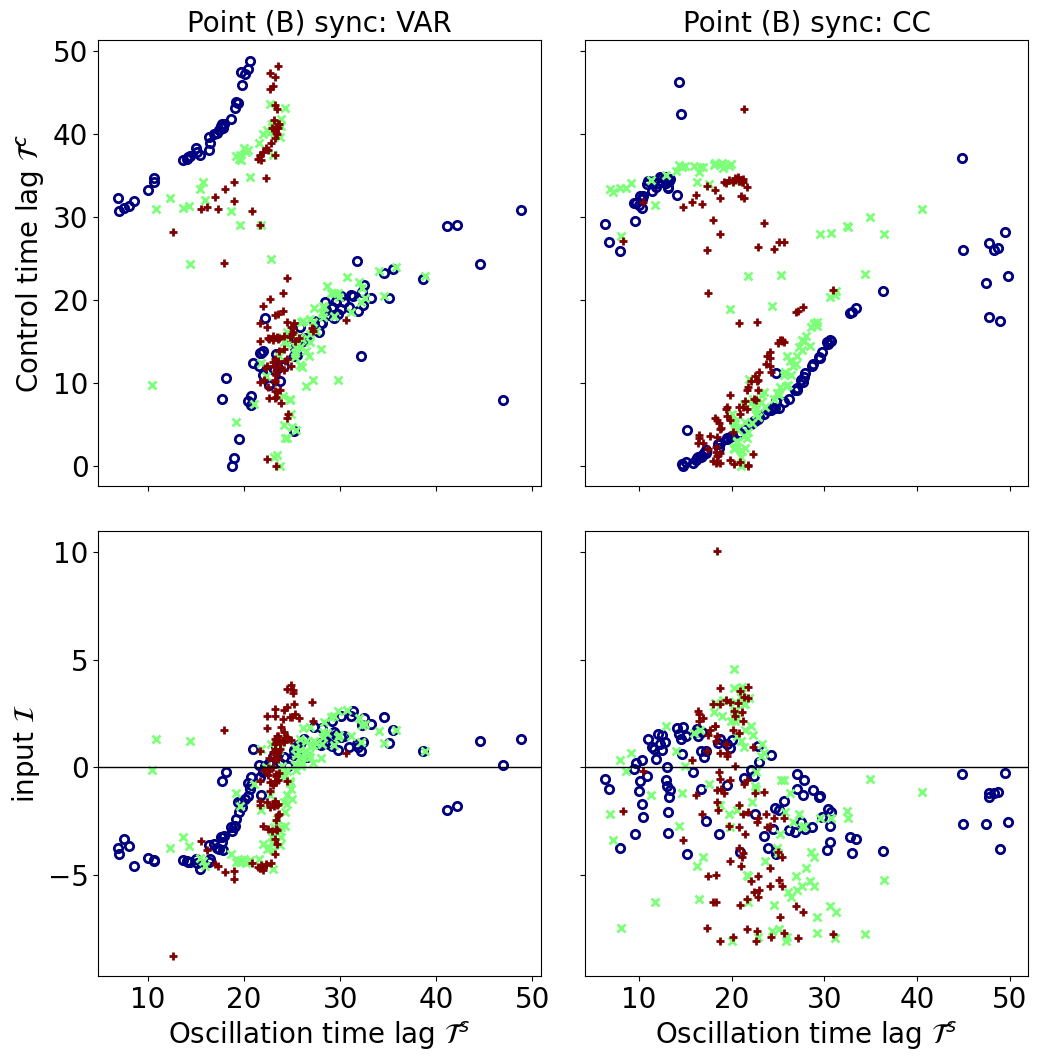

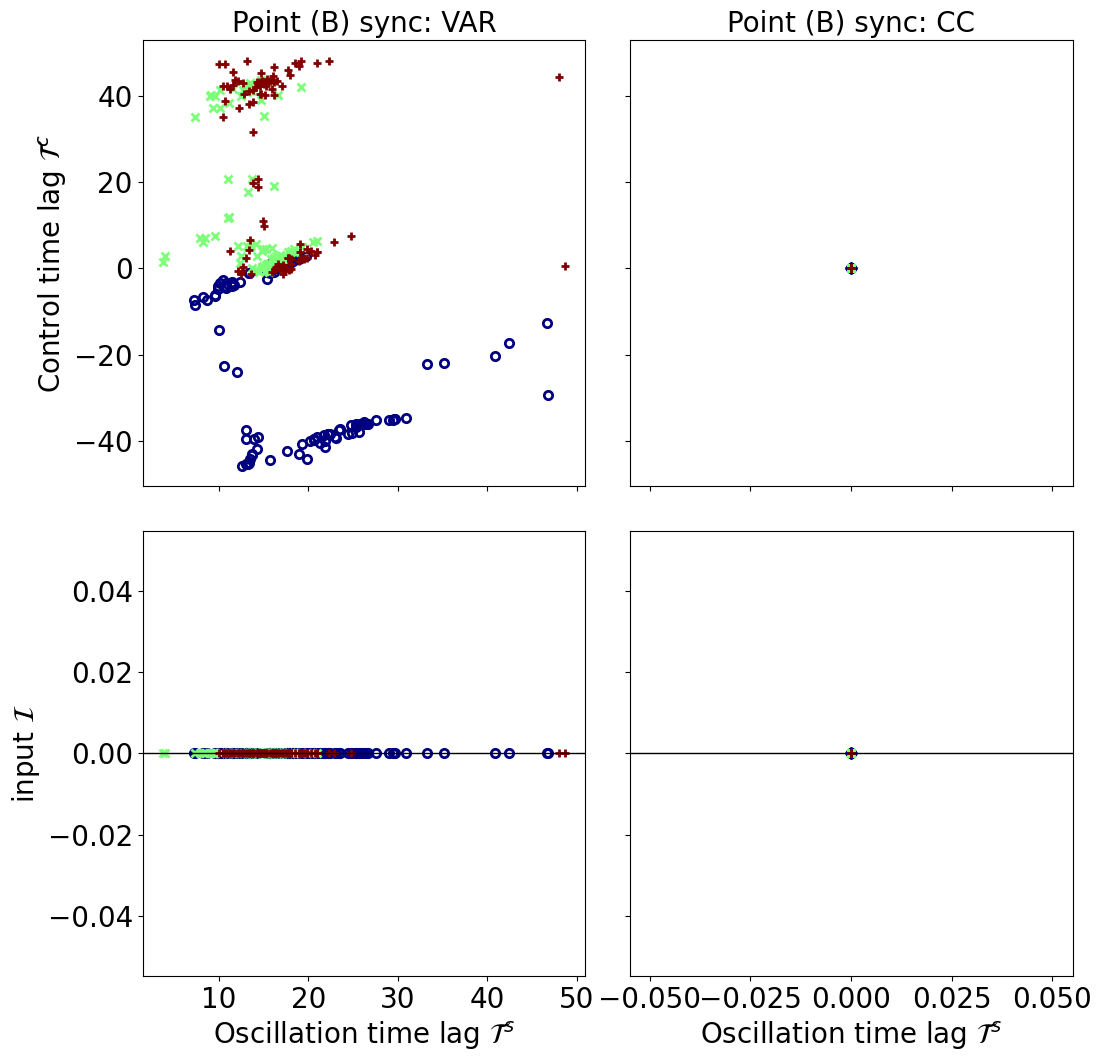

In [153]:
xlabel = r"Oscillation time lag $\mathcal{T}^s$"
ylabel = [r"Control time lag $\mathcal{T}^c$", r"input $\mathcal{I}$"]
titles = ["Point (B) sync: VAR", "Point (B) sync: CC"]

#### cost comb // point // weight // n

colmap = mpl.cm.get_cmap('jet')
marker= ["o", "x", "+"]

x_array = peak_times[0,:]
y_array = [control_times, input]

fig, ax = plt.subplots(len(y_array), 2, figsize=(12,12), sharey="row")

for wi in range(3):
    ax[0,0].plot(peak_times[0, 1, wi, :], control_times[0, 1, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")
    ax[1,0].plot(peak_times[0, 1, wi, :], input[0, 1, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")
    ax[0,1].plot(peak_times[2, 1, wi, :], control_times[2, 1, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")
    ax[1,1].plot(peak_times[2, 1, wi, :], input[2, 1, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")

ax[0,0].set_ylabel(ylabel[0])
ax[1,0].set_ylabel(ylabel[1])

for ix in range(2):
    ax[0,ix].set_xticklabels([])
    ax[0,ix].set_title(titles[ix])
    ax[1,ix].axhline(y=0, color='k')
    ax[1,ix].set_xlabel(xlabel)

plt.subplots_adjust(left=None, bottom=0.1, right=None, top=None, wspace=0.1, hspace=0.1)
plt.savefig(os.path.join(datadir, "times_input_all_sync_L2.jpg"), bbox_inches='tight', dpi=300)
plt.show()

fig, ax = plt.subplots(len(y_array), 2, figsize=(12,12), sharey="row")

for wi in range(3):
    ax[0,0].plot(peak_times[1, 1, wi, :], control_times[1, 1, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")
    ax[1,0].plot(peak_times[1, 1, wi, :], input[1, 1, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")
    ax[0,1].plot(peak_times[3, 1, wi, :], control_times[3, 1, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")
    ax[1,1].plot(peak_times[3, 1, wi, :], input[3, 1, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi/2), linestyle="none")

ax[0,0].set_ylabel(ylabel[0])
ax[1,0].set_ylabel(ylabel[1])

for ix in range(2):
    ax[0,ix].set_xticklabels([])
    ax[0,ix].set_title(titles[ix])
    ax[1,ix].axhline(y=0, color='k')
    ax[1,ix].set_xlabel(xlabel)

plt.subplots_adjust(left=None, bottom=0.1, right=None, top=None, wspace=0.1, hspace=0.1)
plt.savefig(os.path.join(datadir, "times_input_all_sync_L1.jpg"), bbox_inches='tight', dpi=300)
plt.show()

In [155]:
x_array = [av_c, wnd, nfl, coord_data[:,0], coord_data[:,1], coord_data[:,2], r]
xlabel = ["Average controllability", "Weighted node degree", "Relative fiber length", "x coordinate", "y coordinate", "z coordinate", "r coordinate"]
ylabel = ["Oscillation peak time", "Control peak time", "Node input", "Node energy"]

wi = 1
y_array = [peak_times, control_times, input, energy]

r_mat_sc_cd = np.zeros((len(x_array), len(y_array)))
p_mat_sc_cd = np.zeros((len(x_array), len(y_array)))
tot_count_mat = np.zeros((len(x_array), len(y_array)))

for ix, x in enumerate(x_array):
    for iy, y in enumerate(y_array):

        print(xlabel[ix], ylabel[iy])

        result = 0. 
        count_total = 0

        for task in [0,2]:
            for point in [2,0]:
                for wi in range(3):

                    result = scipy.stats.pearsonr(x, y[task, point, wi, :], method=method)
                    r_val = result.statistic
                    p_val = result.pvalue
                    tot_count_mat[ix,iy] += 1
                    if p_val < 0.05:
                        r_mat_sc_cd[ix, iy] += r_val
                        p_mat_sc_cd[ix, iy] += 1

Average controllability Oscillation peak time
Average controllability Control peak time
Average controllability Node input
Average controllability Node energy
Weighted node degree Oscillation peak time
Weighted node degree Control peak time
Weighted node degree Node input
Weighted node degree Node energy
Relative fiber length Oscillation peak time
Relative fiber length Control peak time
Relative fiber length Node input
Relative fiber length Node energy
x coordinate Oscillation peak time
x coordinate Control peak time
x coordinate Node input
x coordinate Node energy
y coordinate Oscillation peak time
y coordinate Control peak time
y coordinate Node input
y coordinate Node energy
z coordinate Oscillation peak time
z coordinate Control peak time
z coordinate Node input
z coordinate Node energy
r coordinate Oscillation peak time
r coordinate Control peak time
r coordinate Node input
r coordinate Node energy


[12. 12. 12. 11.]
[12. 12. 12. 12.]


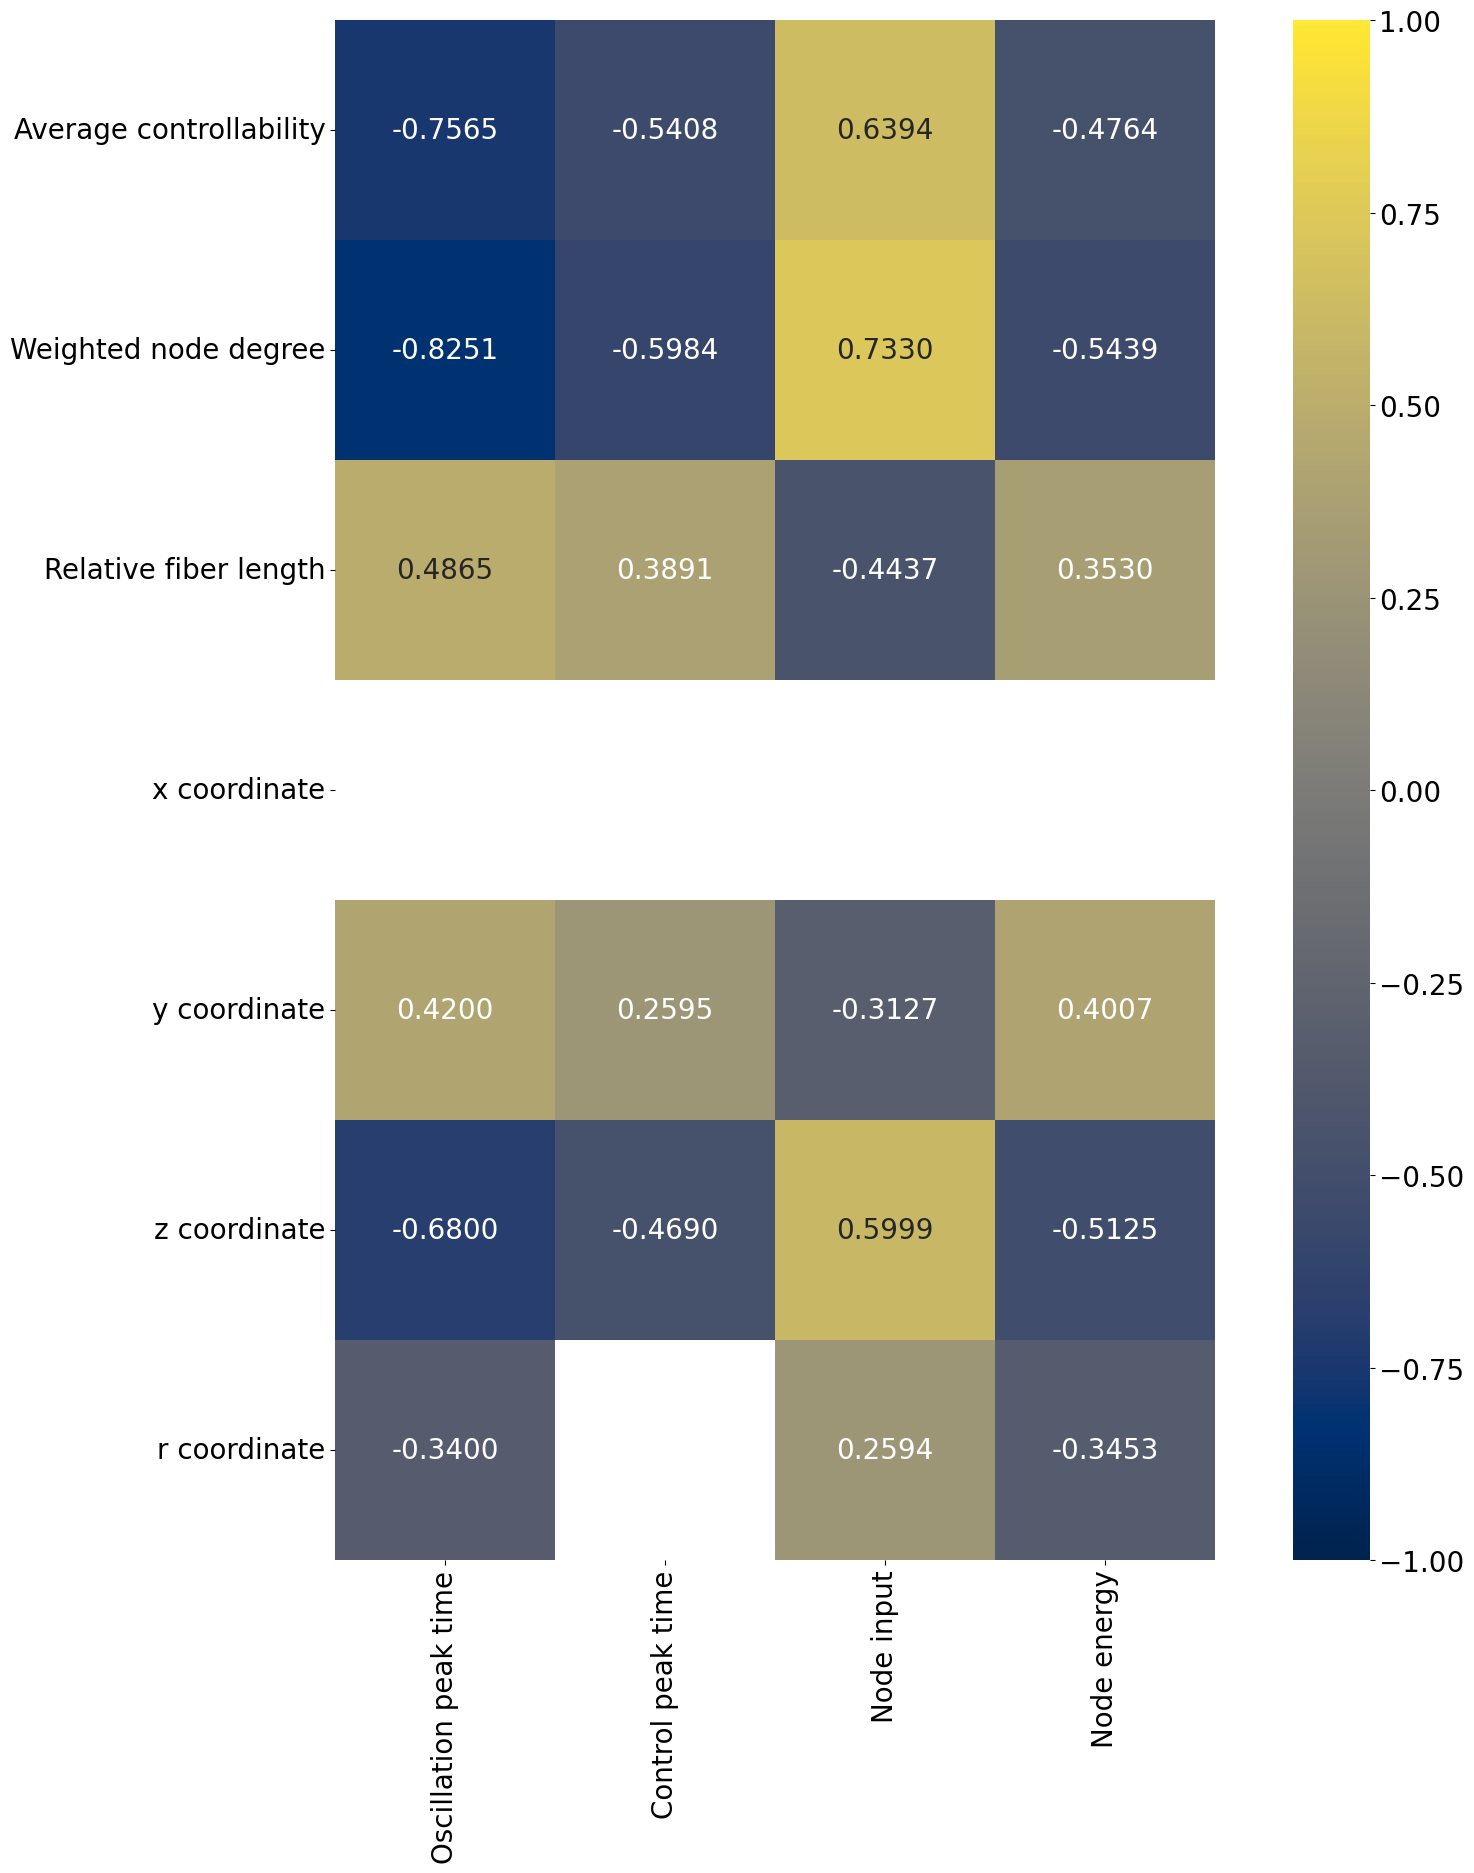

In [156]:
annotations = r_mat_sc_cd.copy()

print(p_mat_sc_cd[1,:])
print(tot_count_mat[1,:])

for ix, x in enumerate(xlabel):
    for iy, y in enumerate(ylabel):
        
        if p_mat_sc_cd[ix, iy]/float(tot_count_mat[ix,iy]) <=0.5:
            annotations[ix, iy] = None
        else:
            annotations[ix,iy] /= p_mat_sc_cd[ix, iy]

plt.figure(figsize=(20,20))
ax = sns.heatmap(annotations, annot=True, fmt='.4f', cmap=cmap, yticklabels=xlabel, xticklabels=ylabel, vmin=-1, vmax=1)
#for ind in [[0,0], [2,0], [0,1], [1,1], [2,1], [0,5]]:
#    rect = plt.Rectangle(ind, 1,1, color="red", linewidth=3, fill=False, clip_on=False)
#    ax.add_patch(rect)
ax.set_aspect('equal', adjustable='box')
plt.xticks(rotation=90) 
plt.savefig(os.path.join(datadir, "sc_cd_desync.jpg"), bbox_inches='tight', dpi=300)
plt.show()

In [132]:
x_array = [av_c, wnd, nfl, coord_data[:,0], coord_data[:,1], coord_data[:,2], r]
xlabel = ["Average controllability", "Weighted node degree", "Relative fiber length", "x coordinate", "y coordinate", "z coordinate", "r coordinate"]
ylabel = ["Oscillation peak time", "Control peak time", "Node input", "Node energy"]

wi = 1
y_array = [peak_times, control_times, input, energy]

r_mat_sc_cd_sync = np.zeros((len(x_array), len(y_array)))
p_mat_sc_cd_sync = np.zeros((len(x_array), len(y_array)))
tot_count_mat_sync = np.zeros((len(x_array), len(y_array)))

for ix, x in enumerate(x_array):
    for iy, y in enumerate(y_array):

        print(xlabel[ix], ylabel[iy])

        result = 0. 
        count_total = 0

        for task in [0]:
            for point in [1]:
                for wi in range(3):
                    result = scipy.stats.pearsonr(x, y[task, point, wi, :], method=method)
                    r_val = result.statistic
                    p_val = result.pvalue
                    tot_count_mat_sync[ix,iy] += 1
                    if p_val < 0.05:
                        r_mat_sc_cd_sync[ix, iy] += r_val
                        p_mat_sc_cd_sync[ix, iy] += 1

Average controllability Oscillation peak time
Average controllability Control peak time
Average controllability Node input
Average controllability Node energy
Weighted node degree Oscillation peak time
Weighted node degree Control peak time
Weighted node degree Node input
Weighted node degree Node energy
Relative fiber length Oscillation peak time
Relative fiber length Control peak time
Relative fiber length Node input
Relative fiber length Node energy
x coordinate Oscillation peak time
x coordinate Control peak time
x coordinate Node input
x coordinate Node energy
y coordinate Oscillation peak time
y coordinate Control peak time
y coordinate Node input
y coordinate Node energy
z coordinate Oscillation peak time
z coordinate Control peak time
z coordinate Node input
z coordinate Node energy
r coordinate Oscillation peak time
r coordinate Control peak time
r coordinate Node input
r coordinate Node energy


[3. 0. 3. 0.]
[3. 3. 3. 3.]


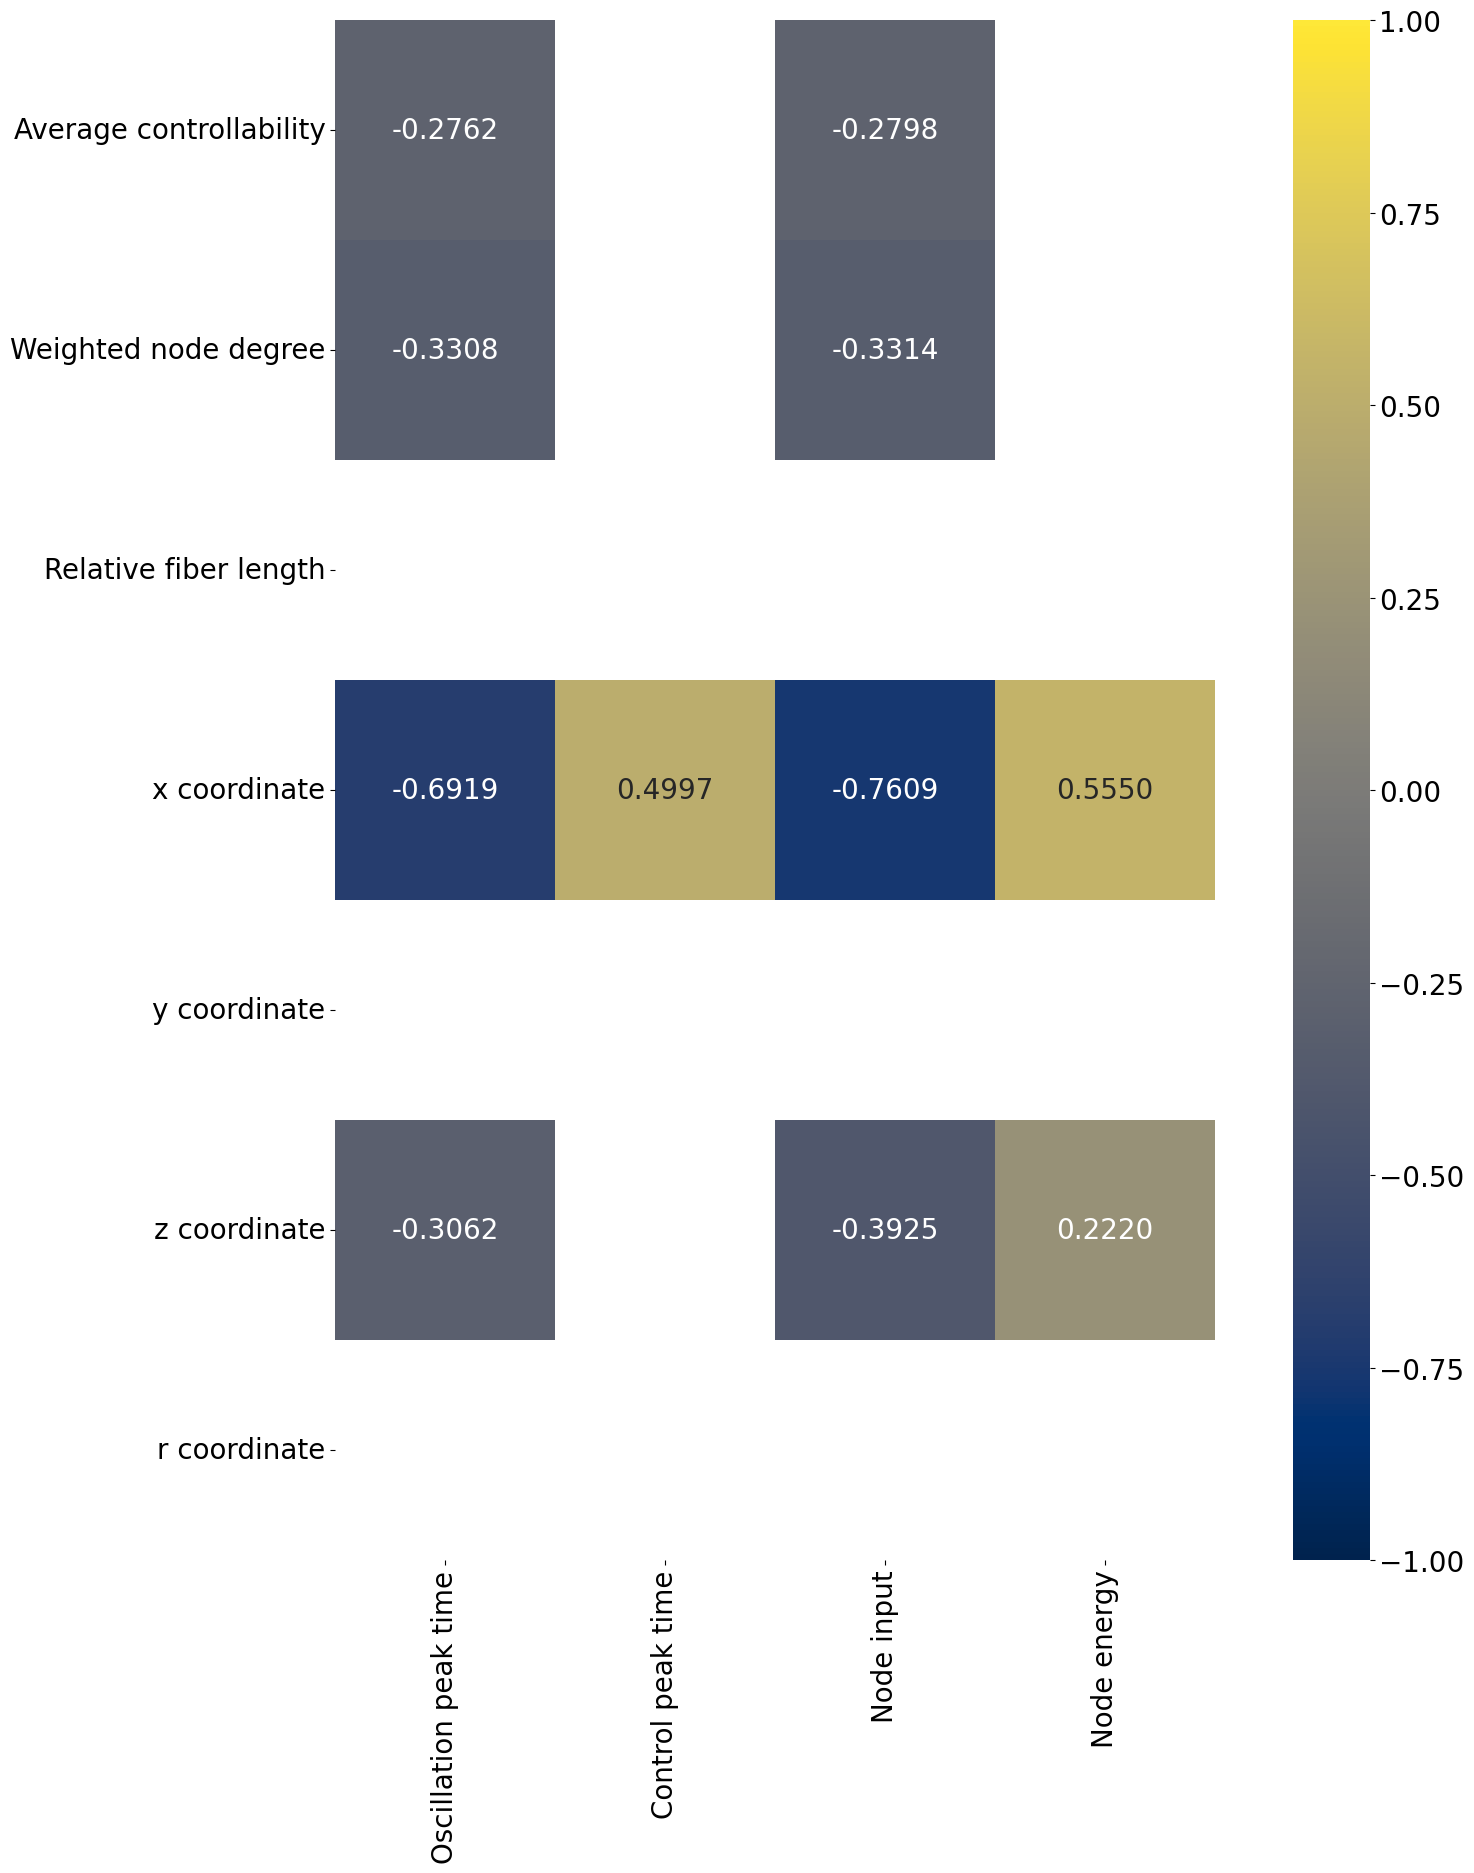

In [133]:
annotations = r_mat_sc_cd_sync.copy()

print(p_mat_sc_cd_sync[1,:])
print(tot_count_mat_sync[1,:])

for ix, x in enumerate(xlabel):
    for iy, y in enumerate(ylabel):
        
        if p_mat_sc_cd_sync[ix, iy]/float(tot_count_mat_sync[ix,iy]) <=0.5:
            annotations[ix, iy] = None
        else:
            annotations[ix,iy] /= p_mat_sc_cd_sync[ix, iy]

plt.figure(figsize=(20,20))
ax = sns.heatmap(annotations, annot=True, fmt='.4f', cmap=cmap, yticklabels=xlabel, xticklabels=ylabel, vmin=-1, vmax=1)
#for ind in [[0,0], [2,0], [0,1], [1,1], [2,1], [0,5]]:
#    rect = plt.Rectangle(ind, 1,1, color="red", linewidth=3, fill=False, clip_on=False)
#    ax.add_patch(rect)
ax.set_aspect('equal', adjustable='box')
plt.xticks(rotation=90) 
plt.savefig(os.path.join(datadir, "sc_cd_sync.jpg"), bbox_inches='tight', dpi=300)
plt.show()